# SDV Models: Comprehensive Evaluation - Wine Quality (White Wine)

This notebook evaluates four synthetic data generation models on the **White Wine Quality** dataset:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using fidelity metrics (KS, JS divergence, Wasserstein) and utility (TSTR/TRTR with 10 classifiers). Target variable: **quality** (multiclass).


## 1. Data Loading and Setup


In [1]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
import warnings
warnings.filterwarnings('ignore')

# Load White Wine Quality dataset (semicolon-separated)
# Path works when run from project root or from Notebooks folder
import os
_csv_paths = [
    'Datasets/wine+quality/winequality-white.csv',
    '../Datasets/wine+quality/winequality-white.csv',
]
csv_path = next((p for p in _csv_paths if os.path.exists(p)), _csv_paths[0])
wine_data = pd.read_csv(csv_path, sep=';')

# Basic info
print("Data shape:", wine_data.shape)
print("Columns:", list(wine_data.columns))
print("\nQuality distribution:")
print(wine_data['quality'].value_counts().sort_index())

# Detect metadata for SDV
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(wine_data)
print(f"\nMetadata detected. Columns: {len(wine_data.columns)}")

Data shape: (4898, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Quality distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

Metadata detected. Columns: 12


## 2. Helper Functions – Plotting and TSTR/TRTR Evaluation


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_comparison_all_models(results_df, metric='AUC', title_suffix=''):
    trtr_col = f"{metric}_TRTR"
    tstr_col = f"{metric}_TSTR"
    if trtr_col not in results_df.columns or tstr_col not in results_df.columns:
        print(f"Warning: {trtr_col} or {tstr_col} not found")
        return
    results_df = results_df.copy()
    results_df['Drop'] = results_df[trtr_col] - results_df[tstr_col]
    results_df = results_df.sort_values('Drop', ascending=False)
    x = np.arange(len(results_df))
    w = 0.35
    plt.figure(figsize=(14, 6))
    plt.bar(x - w/2, results_df[trtr_col], w, label=f'{metric} TRTR', alpha=0.8)
    plt.bar(x + w/2, results_df[tstr_col], w, label=f'{metric} TSTR', alpha=0.8)
    plt.xticks(x, results_df["Model"], rotation=45, ha='right')
    plt.ylabel(metric)
    plt.title(f'TRTR vs TSTR ({metric}){title_suffix}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_metric_drop(results_df, metric='AUC', title_suffix=''):
    trtr_col = f"{metric}_TRTR"
    tstr_col = f"{metric}_TSTR"
    if trtr_col not in results_df.columns or tstr_col not in results_df.columns:
        return
    results_df = results_df.copy()
    results_df[f'{metric}_Drop'] = results_df[trtr_col] - results_df[tstr_col]
    results_df = results_df.sort_values(f'{metric}_Drop', ascending=False)
    x = np.arange(len(results_df))
    plt.figure(figsize=(14, 6))
    colors = plt.cm.RdYlGn_r((results_df[f'{metric}_Drop'] - results_df[f'{metric}_Drop'].min()) / 
                              (results_df[f'{metric}_Drop'].max() - results_df[f'{metric}_Drop'].min() + 1e-10))
    plt.bar(x, results_df[f'{metric}_Drop'], color=colors, alpha=0.7)
    plt.xticks(x, results_df["Model"], rotation=45, ha='right')
    plt.ylabel(f'{metric} Drop (TRTR - TSTR)')
    plt.title(f'{metric} Drop from TRTR to TSTR{title_suffix}')
    plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

def create_comprehensive_comparison(results_df, model_name=''):
    for metric in ['AUC', 'Accuracy', 'F1', 'Precision', 'Recall']:
        try:
            plot_comparison_all_models(results_df, metric=metric, title_suffix=f' - {model_name}' if model_name else '')
            plot_metric_drop(results_df, metric=metric, title_suffix=f' - {model_name}' if model_name else '')
        except Exception as e:
            print(f"Error plotting {metric}: {e}")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

models_dict = {
    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees': ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'MLP': MLPClassifier(max_iter=2000, random_state=42),
}

def _get_auc_multiclass(y_true, y_proba):
    if y_proba is None or len(np.unique(y_true)) < 2:
        return float("nan")
    try:
        return roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        return float("nan")

def evaluate_tstr_trtr_10models(real_data, synthetic_data=None, target_col='quality', models=None,
                                 test_size=0.2, random_state=42, name='Model'):
    if models is None:
        models = models_dict
    if target_col not in real_data.columns:
        print(f"[{name}] Target '{target_col}' not in real_data. Skipping.")
        return None
    X_real = real_data.drop(columns=[target_col])
    y_real = real_data[target_col]
    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        X_real, y_real, test_size=test_size, random_state=random_state, stratify=y_real
    )
    scaler_trtr = StandardScaler().fit(X_train_real)
    X_train_real_scaled = scaler_trtr.transform(X_train_real)
    X_test_real_scaled = scaler_trtr.transform(X_test_real)
    results = []
    for model_name, clf in models.items():
        print(f"\n===== {name} | {model_name} =====")
        clf_trtr = type(clf)(**clf.get_params()) if hasattr(clf, 'get_params') else clf
        clf_trtr.fit(X_train_real_scaled, y_train_real)
        y_pred_trtr = clf_trtr.predict(X_test_real_scaled)
        y_prob_trtr = clf_trtr.predict_proba(X_test_real_scaled) if hasattr(clf_trtr, "predict_proba") else None
        auc_trtr = _get_auc_multiclass(y_test_real, y_prob_trtr)
        acc_trtr = accuracy_score(y_test_real, y_pred_trtr)
        f1_trtr = f1_score(y_test_real, y_pred_trtr, average='weighted')
        prec_trtr = precision_score(y_test_real, y_pred_trtr, average='weighted', zero_division=0)
        rec_trtr = recall_score(y_test_real, y_pred_trtr, average='weighted', zero_division=0)
        print(f"[TRTR] Accuracy={acc_trtr:.3f}, F1={f1_trtr:.3f}, AUC={auc_trtr:.3f}")
        acc_tstr = f1_tstr = prec_tstr = rec_tstr = auc_tstr = None
        if synthetic_data is not None and target_col in synthetic_data.columns:
            X_synth = synthetic_data.drop(columns=[target_col])
            y_synth = synthetic_data[target_col]
            stratify_synth = y_synth if (y_synth.value_counts() >= 2).all() else None
            X_train_synth, _, y_train_synth, _ = train_test_split(
                X_synth, y_synth, test_size=test_size, random_state=random_state, stratify=stratify_synth
            )
            scaler_tstr = StandardScaler().fit(X_train_synth)
            X_train_synth_scaled = scaler_tstr.transform(X_train_synth)
            X_test_real_scaled_tstr = scaler_tstr.transform(X_test_real)
            clf_tstr = type(clf)(**clf.get_params()) if hasattr(clf, 'get_params') else clf
            clf_tstr.fit(X_train_synth_scaled, y_train_synth)
            y_pred_tstr = clf_tstr.predict(X_test_real_scaled_tstr)
            y_prob_tstr = clf_tstr.predict_proba(X_test_real_scaled_tstr) if hasattr(clf_tstr, "predict_proba") else None
            auc_tstr = _get_auc_multiclass(y_test_real, y_prob_tstr)
            acc_tstr = accuracy_score(y_test_real, y_pred_tstr)
            f1_tstr = f1_score(y_test_real, y_pred_tstr, average='weighted')
            prec_tstr = precision_score(y_test_real, y_pred_tstr, average='weighted', zero_division=0)
            rec_tstr = recall_score(y_test_real, y_pred_tstr, average='weighted', zero_division=0)
            print(f"[TSTR] Accuracy={acc_tstr:.3f}, F1={f1_tstr:.3f}, AUC={auc_tstr:.3f}")
        results.append({
            "Model": model_name,
            "Accuracy_TRTR": acc_trtr, "F1_TRTR": f1_trtr, "Precision_TRTR": prec_trtr,
            "Recall_TRTR": rec_trtr, "AUC_TRTR": auc_trtr,
            "Accuracy_TSTR": acc_tstr, "F1_TSTR": f1_tstr, "Precision_TSTR": prec_tstr,
            "Recall_TSTR": rec_tstr, "AUC_TSTR": auc_tstr,
        })
    return pd.DataFrame(results).sort_values(by="AUC_TRTR", ascending=False)

## 3. Generate Synthetic Data (SDV Models)


In [8]:
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

models = {
    'CTGAN': CTGANSynthesizer,
    'CopulaGAN': CopulaGANSynthesizer,
    'TVAE': TVAESynthesizer,
    'GaussianCopula': GaussianCopulaSynthesizer
}

synthetic_data = {}
diagnostics = {}
quality_report = {}

for name, Synthesizer in models.items():
    print(f"\nSynthesizing with {name}...")
    model = Synthesizer(metadata)
    model.fit(wine_data)
    synthetic_data[name] = model.sample(min(2000, len(wine_data)))
    diagnostics[name] = run_diagnostic(wine_data, synthetic_data[name], metadata)
    quality_report[name] = evaluate_quality(wine_data, synthetic_data[name], metadata)
    print(f'{name} synthetic data generated successfully!')

print("=========================================")
for name in models:
    print(f"Diagnostics for {name}:")
    print(diagnostics[name])
    print("-" * 40)
print("=========================================")
for name in models:
    print(f"Quality report for {name}:")
    print(quality_report[name])
    print("-" * 40)


Synthesizing with CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 1200.00it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 49.05it/s]|
Column Shapes Score: 81.55%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 282.26it/s]|
Column Pair Trends Score: 83.88%

Overall Score (Average): 82.72%

CTGAN synthetic data generated successfully!

Synthesizing with CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 942.66it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 333.15it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:

## 4. TSTR/TRTR Evaluation with 10 Classifiers


In [11]:
label_col = 'quality'
all_results = {}

for model_name in ['CTGAN', 'CopulaGAN', 'TVAE', 'GaussianCopula']:
    if model_name in synthetic_data:
        print(f"\n{'='*60}")
        print(f"Evaluating {model_name}")
        print(f"{'='*60}")
        results_df = evaluate_tstr_trtr_10models(
            real_data=wine_data,
            synthetic_data=synthetic_data[model_name],
            target_col=label_col,
            name=model_name
        )
        if results_df is not None:
            all_results[model_name] = results_df
            display(results_df)

print(f"\nEvaluation complete for {len(all_results)} models.")


Evaluating CTGAN

===== CTGAN | LogReg =====
[TRTR] Accuracy=0.528, F1=0.479, AUC=0.703
[TSTR] Accuracy=0.316, F1=0.323, AUC=0.643

===== CTGAN | SVM-RBF =====
[TRTR] Accuracy=0.566, F1=0.533, AUC=0.751
[TSTR] Accuracy=0.333, F1=0.349, AUC=0.644

===== CTGAN | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718
[TSTR] Accuracy=0.285, F1=0.313, AUC=0.576

===== CTGAN | NaiveBayes =====
[TRTR] Accuracy=0.472, F1=0.467, AUC=0.676
[TSTR] Accuracy=0.304, F1=0.316, AUC=0.632

===== CTGAN | DecisionTree =====
[TRTR] Accuracy=0.594, F1=0.594, AUC=0.700
[TSTR] Accuracy=0.273, F1=0.315, AUC=0.537

===== CTGAN | RandomForest =====
[TRTR] Accuracy=0.676, F1=0.664, AUC=0.850
[TSTR] Accuracy=0.341, F1=0.362, AUC=0.623

===== CTGAN | ExtraTrees =====
[TRTR] Accuracy=0.658, F1=0.648, AUC=0.853
[TSTR] Accuracy=0.339, F1=0.355, AUC=0.624

===== CTGAN | GradientBoost =====
[TRTR] Accuracy=0.576, F1=0.562, AUC=0.756
[TSTR] Accuracy=0.344, F1=0.365, AUC=0.630

===== CTGAN | AdaBoost =====
[TRTR] Accuracy

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR
6,ExtraTrees,0.658163,0.648258,0.661986,0.658163,0.853242,0.338776,0.355035,0.410699,0.338776,0.624198
5,RandomForest,0.675510,0.664390,0.683985,0.675510,0.849558,0.340816,0.361714,0.425506,0.340816,0.623232
7,GradientBoost,0.575510,0.562013,0.579762,0.575510,0.755638,0.343878,0.365334,0.443067,0.343878,0.629528
1,SVM-RBF,0.566327,0.532779,0.572189,0.566327,0.750546,0.332653,0.349066,0.407125,0.332653,0.644251
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.292857,0.325839,0.417576,0.292857,0.604467
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.284694,0.313449,0.411903,0.284694,0.576461
0,LogReg,0.527551,0.478813,0.486431,0.527551,0.702990,0.316327,0.323355,0.407250,0.316327,0.643423
4,DecisionTree,0.593878,0.594230,0.595350,0.593878,0.700120,0.273469,0.314708,0.390521,0.273469,0.536834
3,NaiveBayes,0.472449,0.466507,0.501499,0.472449,0.676294,0.304082,0.315712,0.389449,0.304082,0.631784
8,AdaBoost,0.464286,0.430827,0.442865,0.464286,0.647839,0.318367,0.345825,0.402190,0.318367,0.597662



Evaluating CopulaGAN

===== CopulaGAN | LogReg =====
[TRTR] Accuracy=0.528, F1=0.479, AUC=0.703
[TSTR] Accuracy=0.379, F1=0.399, AUC=0.653

===== CopulaGAN | SVM-RBF =====
[TRTR] Accuracy=0.566, F1=0.533, AUC=0.751
[TSTR] Accuracy=0.397, F1=0.418, AUC=0.641

===== CopulaGAN | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718
[TSTR] Accuracy=0.320, F1=0.352, AUC=0.611

===== CopulaGAN | NaiveBayes =====
[TRTR] Accuracy=0.472, F1=0.467, AUC=0.676
[TSTR] Accuracy=0.380, F1=0.399, AUC=0.640

===== CopulaGAN | DecisionTree =====
[TRTR] Accuracy=0.594, F1=0.594, AUC=0.700
[TSTR] Accuracy=0.266, F1=0.308, AUC=0.543

===== CopulaGAN | RandomForest =====
[TRTR] Accuracy=0.676, F1=0.664, AUC=0.850
[TSTR] Accuracy=0.395, F1=0.418, AUC=0.654

===== CopulaGAN | ExtraTrees =====
[TRTR] Accuracy=0.658, F1=0.648, AUC=0.853
[TSTR] Accuracy=0.387, F1=0.403, AUC=0.643

===== CopulaGAN | GradientBoost =====
[TRTR] Accuracy=0.576, F1=0.562, AUC=0.756
[TSTR] Accuracy=0.370, F1=0.402, AUC=0.660

===== Co

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR
6,ExtraTrees,0.658163,0.648258,0.661986,0.658163,0.853242,0.386735,0.403357,0.449662,0.386735,0.643121
5,RandomForest,0.675510,0.664390,0.683985,0.675510,0.849558,0.394898,0.418410,0.470401,0.394898,0.653668
7,GradientBoost,0.575510,0.562013,0.579762,0.575510,0.755638,0.370408,0.402353,0.471882,0.370408,0.660251
1,SVM-RBF,0.566327,0.532779,0.572189,0.566327,0.750546,0.396939,0.417507,0.465049,0.396939,0.641141
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.305102,0.350967,0.449740,0.305102,0.620920
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.320408,0.352040,0.432010,0.320408,0.610717
0,LogReg,0.527551,0.478813,0.486431,0.527551,0.702990,0.378571,0.399199,0.465828,0.378571,0.653439
4,DecisionTree,0.593878,0.594230,0.595350,0.593878,0.700120,0.266327,0.308448,0.403217,0.266327,0.543256
3,NaiveBayes,0.472449,0.466507,0.501499,0.472449,0.676294,0.379592,0.398513,0.462441,0.379592,0.640040
8,AdaBoost,0.464286,0.430827,0.442865,0.464286,0.647839,0.386735,0.413401,0.478427,0.386735,0.622917



Evaluating TVAE

===== TVAE | LogReg =====
[TRTR] Accuracy=0.528, F1=0.479, AUC=0.703
[TSTR] Accuracy=0.516, F1=0.491, AUC=nan

===== TVAE | SVM-RBF =====
[TRTR] Accuracy=0.566, F1=0.533, AUC=0.751
[TSTR] Accuracy=0.496, F1=0.460, AUC=nan

===== TVAE | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718
[TSTR] Accuracy=0.483, F1=0.448, AUC=nan

===== TVAE | NaiveBayes =====
[TRTR] Accuracy=0.472, F1=0.467, AUC=0.676
[TSTR] Accuracy=0.498, F1=0.475, AUC=nan

===== TVAE | DecisionTree =====
[TRTR] Accuracy=0.594, F1=0.594, AUC=0.700
[TSTR] Accuracy=0.486, F1=0.467, AUC=nan

===== TVAE | RandomForest =====
[TRTR] Accuracy=0.676, F1=0.664, AUC=0.850
[TSTR] Accuracy=0.537, F1=0.506, AUC=nan

===== TVAE | ExtraTrees =====
[TRTR] Accuracy=0.658, F1=0.648, AUC=0.853
[TSTR] Accuracy=0.534, F1=0.502, AUC=nan

===== TVAE | GradientBoost =====
[TRTR] Accuracy=0.576, F1=0.562, AUC=0.756
[TSTR] Accuracy=0.518, F1=0.495, AUC=nan

===== TVAE | AdaBoost =====
[TRTR] Accuracy=0.464, F1=0.431, AUC=0.64

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR
6,ExtraTrees,0.658163,0.648258,0.661986,0.658163,0.853242,0.533673,0.501906,0.490962,0.533673,NaN
5,RandomForest,0.675510,0.664390,0.683985,0.675510,0.849558,0.536735,0.505530,0.492338,0.536735,NaN
7,GradientBoost,0.575510,0.562013,0.579762,0.575510,0.755638,0.518367,0.494559,0.492504,0.518367,NaN
1,SVM-RBF,0.566327,0.532779,0.572189,0.566327,0.750546,0.495918,0.460207,0.451918,0.495918,NaN
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.495918,0.464810,0.450141,0.495918,NaN
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.482653,0.448333,0.435667,0.482653,NaN
0,LogReg,0.527551,0.478813,0.486431,0.527551,0.702990,0.516327,0.490989,0.474179,0.516327,NaN
4,DecisionTree,0.593878,0.594230,0.595350,0.593878,0.700120,0.485714,0.466891,0.450915,0.485714,NaN
3,NaiveBayes,0.472449,0.466507,0.501499,0.472449,0.676294,0.497959,0.475063,0.457590,0.497959,NaN
8,AdaBoost,0.464286,0.430827,0.442865,0.464286,0.647839,0.501020,0.482960,0.466613,0.501020,NaN



Evaluating GaussianCopula

===== GaussianCopula | LogReg =====
[TRTR] Accuracy=0.528, F1=0.479, AUC=0.703
[TSTR] Accuracy=0.459, F1=0.335, AUC=nan

===== GaussianCopula | SVM-RBF =====
[TRTR] Accuracy=0.566, F1=0.533, AUC=0.751
[TSTR] Accuracy=0.443, F1=0.295, AUC=nan

===== GaussianCopula | KNN =====
[TRTR] Accuracy=0.527, F1=0.519, AUC=0.718
[TSTR] Accuracy=0.390, F1=0.358, AUC=nan

===== GaussianCopula | NaiveBayes =====
[TRTR] Accuracy=0.472, F1=0.467, AUC=0.676
[TSTR] Accuracy=0.454, F1=0.379, AUC=nan

===== GaussianCopula | DecisionTree =====
[TRTR] Accuracy=0.594, F1=0.594, AUC=0.700
[TSTR] Accuracy=0.330, F1=0.332, AUC=nan

===== GaussianCopula | RandomForest =====
[TRTR] Accuracy=0.676, F1=0.664, AUC=0.850
[TSTR] Accuracy=0.418, F1=0.337, AUC=nan

===== GaussianCopula | ExtraTrees =====
[TRTR] Accuracy=0.658, F1=0.648, AUC=0.853
[TSTR] Accuracy=0.429, F1=0.341, AUC=nan

===== GaussianCopula | GradientBoost =====
[TRTR] Accuracy=0.576, F1=0.562, AUC=0.756
[TSTR] Accuracy=0.407

,Model,Accuracy_TRTR,F1_TRTR,Precision_TRTR,Recall_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,Precision_TSTR,Recall_TSTR,AUC_TSTR
6,ExtraTrees,0.658163,0.648258,0.661986,0.658163,0.853242,0.428571,0.340568,0.326604,0.428571,NaN
5,RandomForest,0.675510,0.664390,0.683985,0.675510,0.849558,0.418367,0.336921,0.352847,0.418367,NaN
7,GradientBoost,0.575510,0.562013,0.579762,0.575510,0.755638,0.407143,0.345789,0.345692,0.407143,NaN
1,SVM-RBF,0.566327,0.532779,0.572189,0.566327,0.750546,0.442857,0.295332,0.305087,0.442857,NaN
9,MLP,0.551020,0.545594,0.545033,0.551020,0.737484,0.381633,0.359732,0.348999,0.381633,NaN
2,KNN,0.526531,0.519092,0.519928,0.526531,0.718092,0.389796,0.358046,0.345557,0.389796,NaN
0,LogReg,0.527551,0.478813,0.486431,0.527551,0.702990,0.459184,0.334691,0.352492,0.459184,NaN
4,DecisionTree,0.593878,0.594230,0.595350,0.593878,0.700120,0.329592,0.332500,0.336280,0.329592,NaN
3,NaiveBayes,0.472449,0.466507,0.501499,0.472449,0.676294,0.454082,0.378753,0.419879,0.454082,NaN
8,AdaBoost,0.464286,0.430827,0.442865,0.464286,0.647839,0.419388,0.312763,0.330364,0.419388,NaN



Evaluation complete for 4 models.



Comparison Graphs for CTGAN


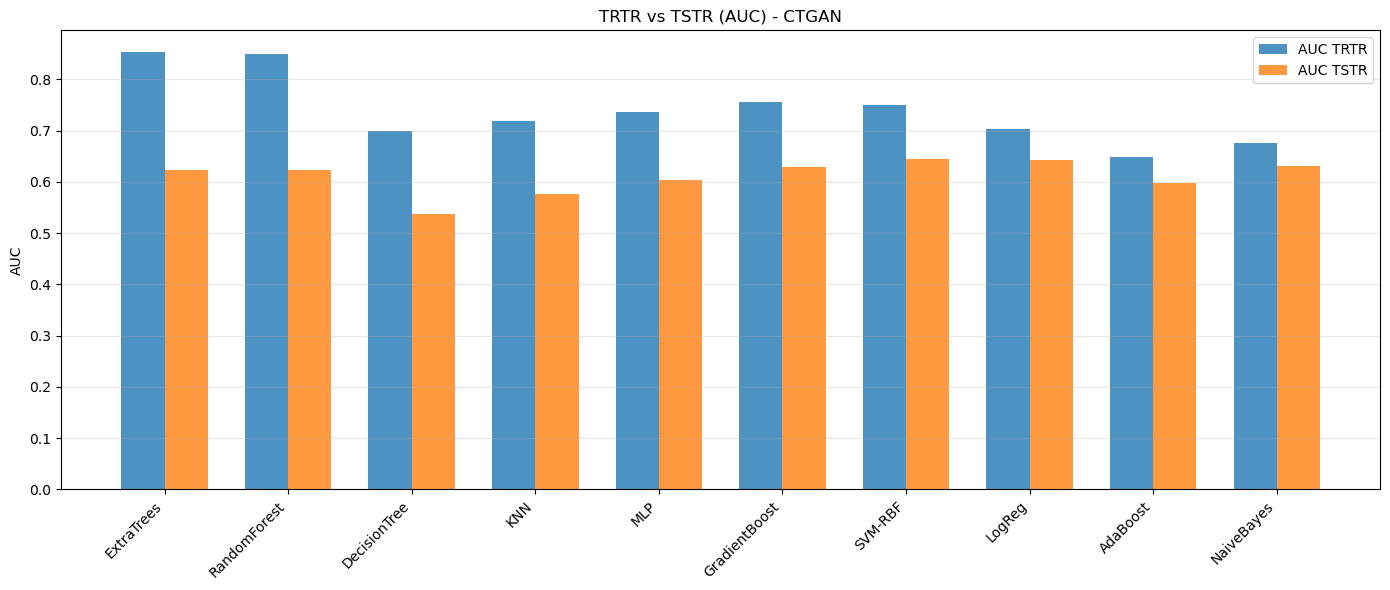

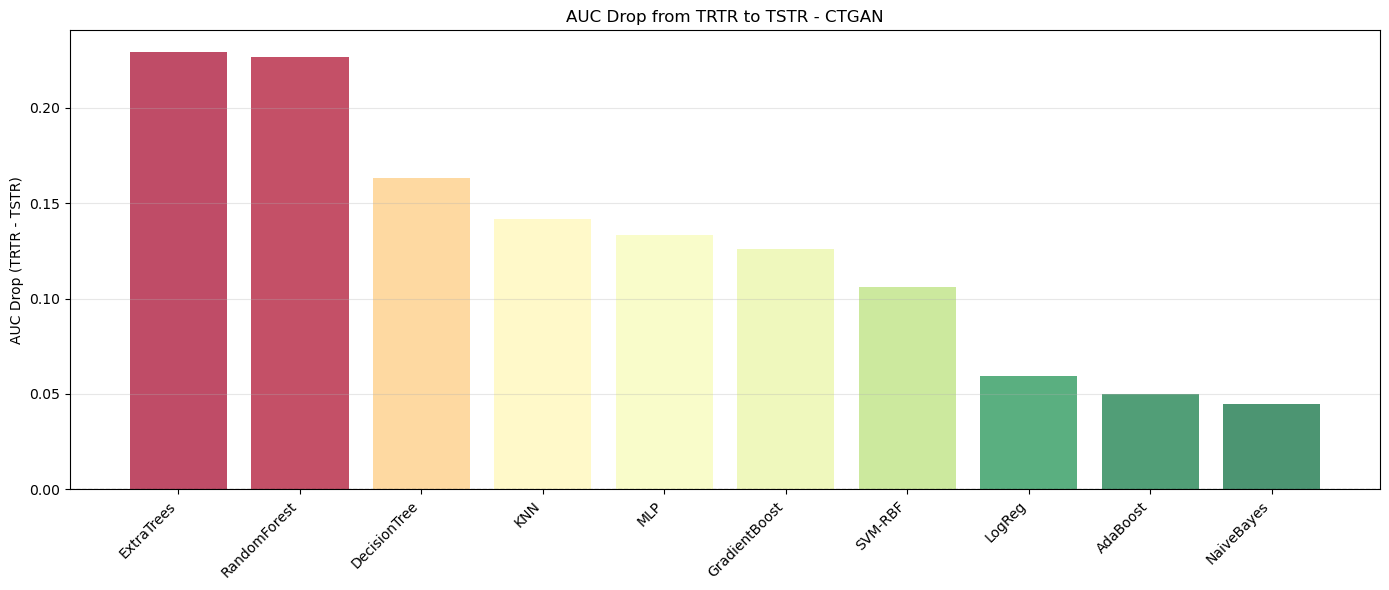

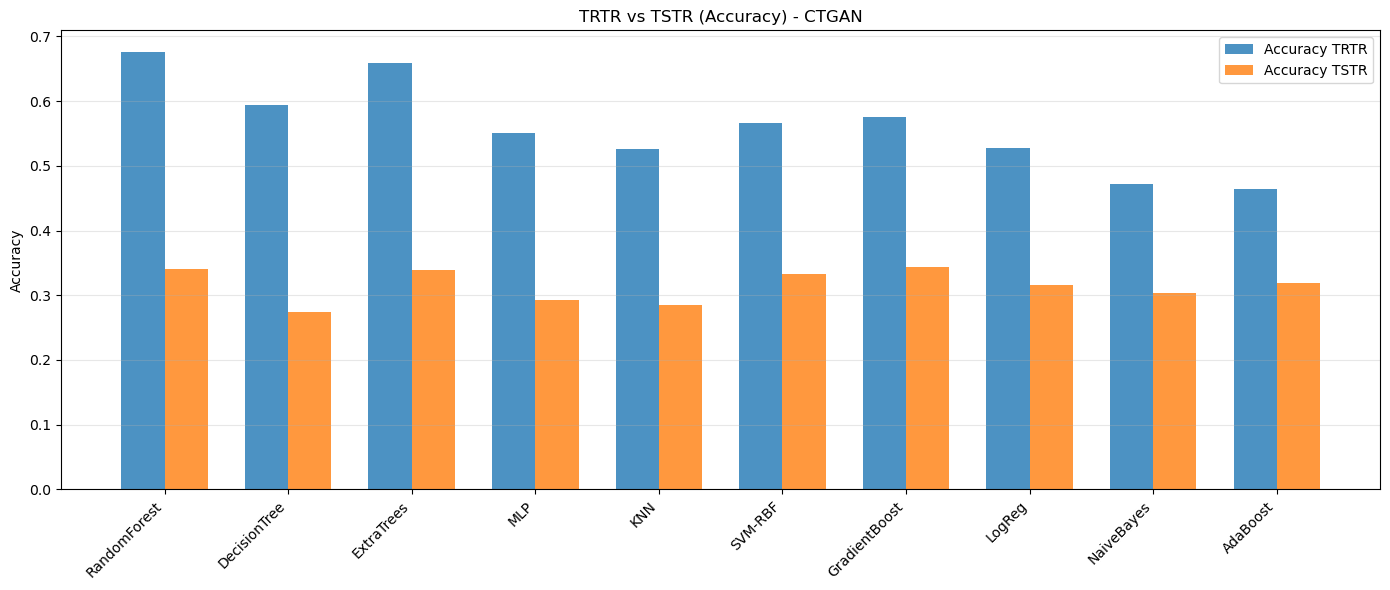

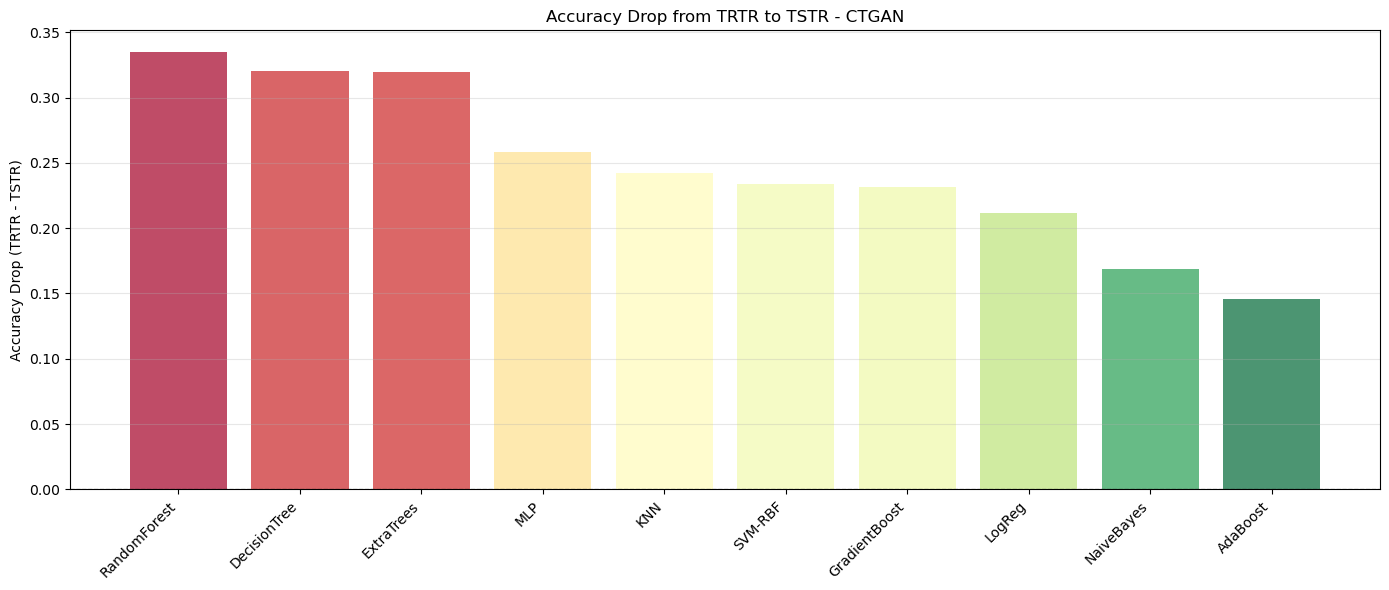

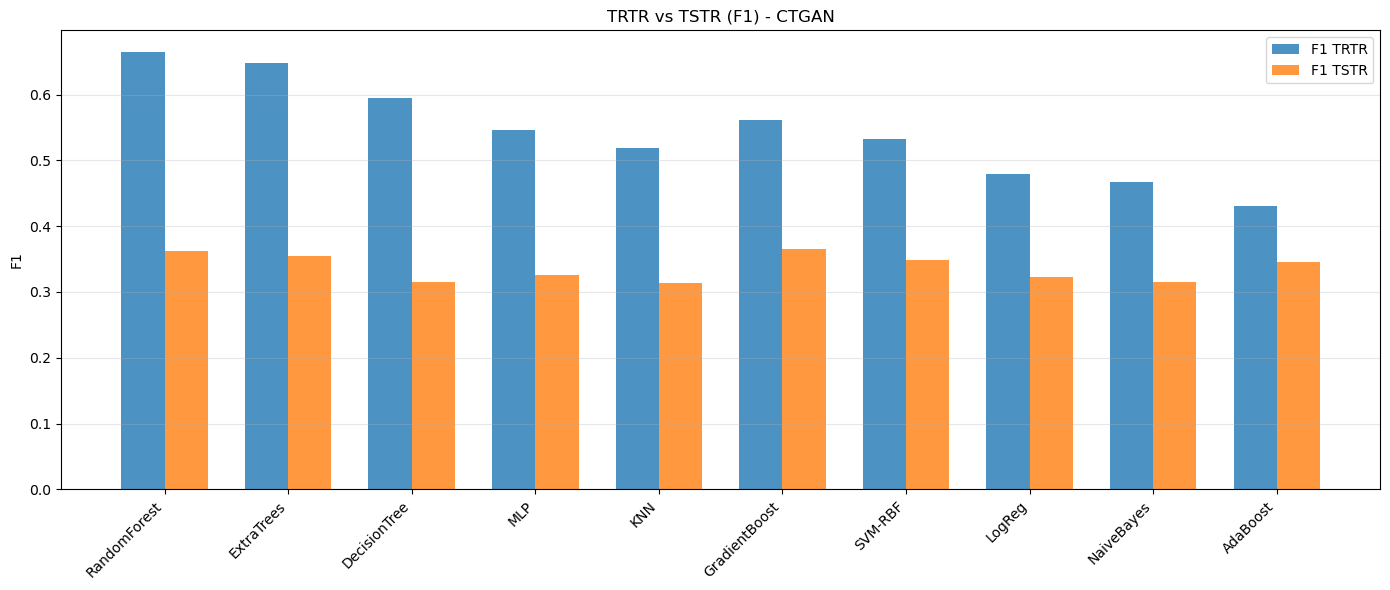

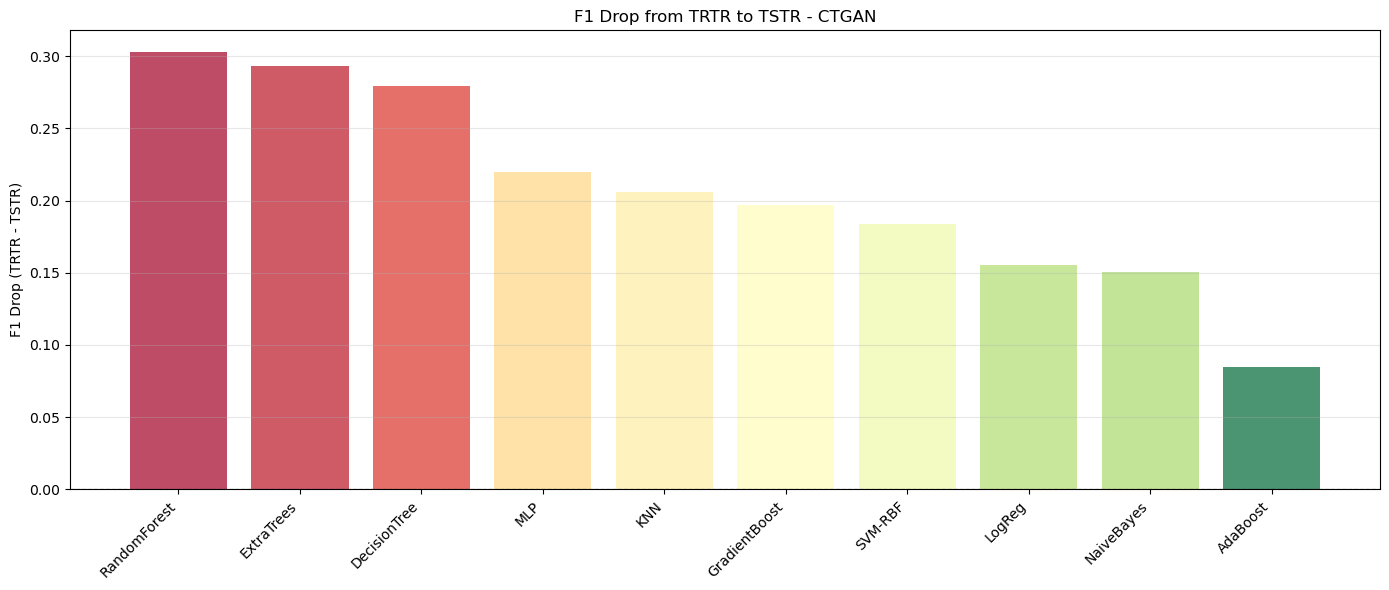

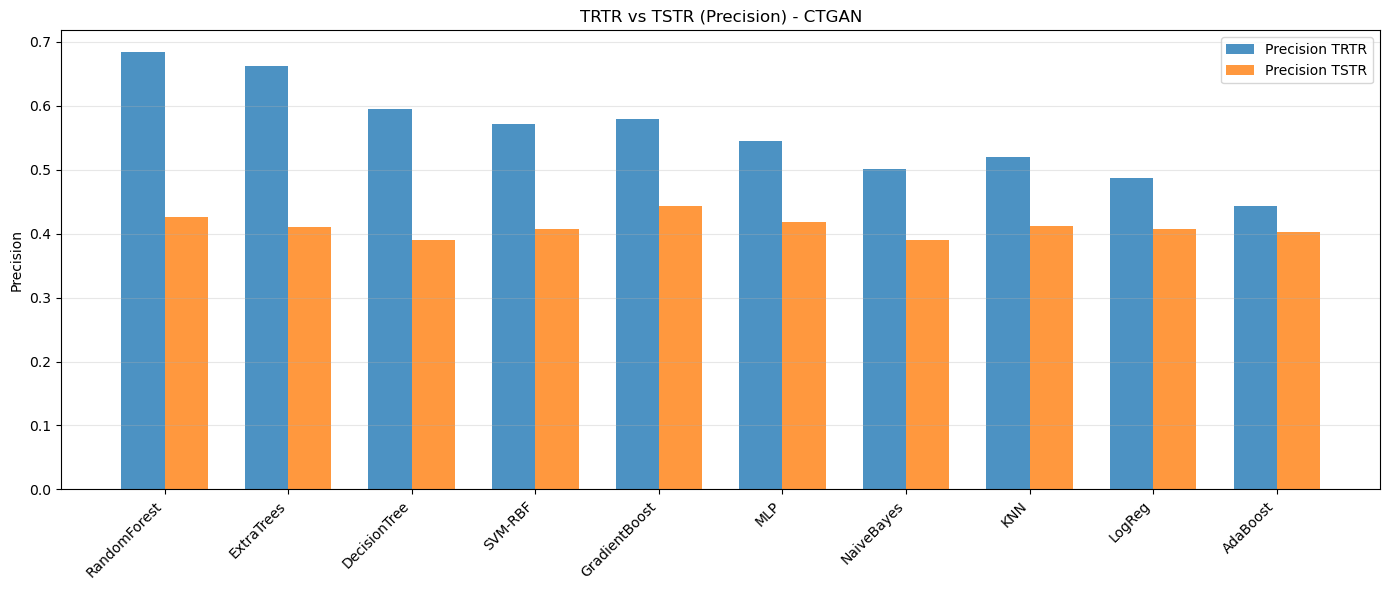

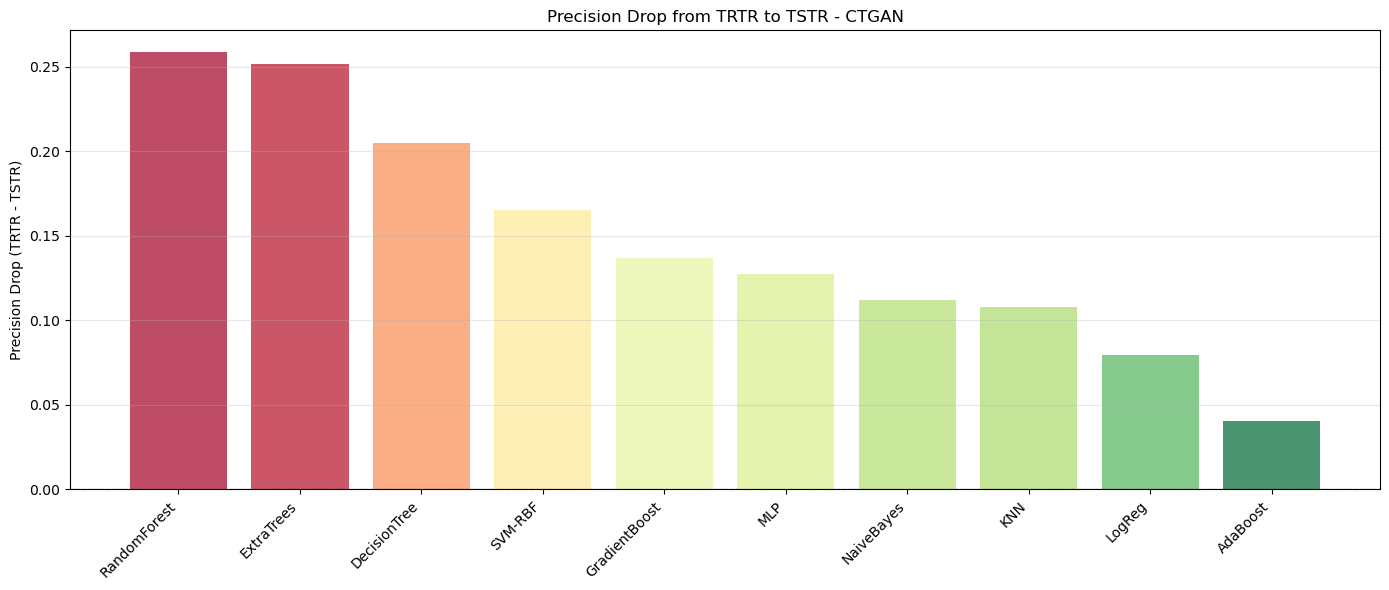

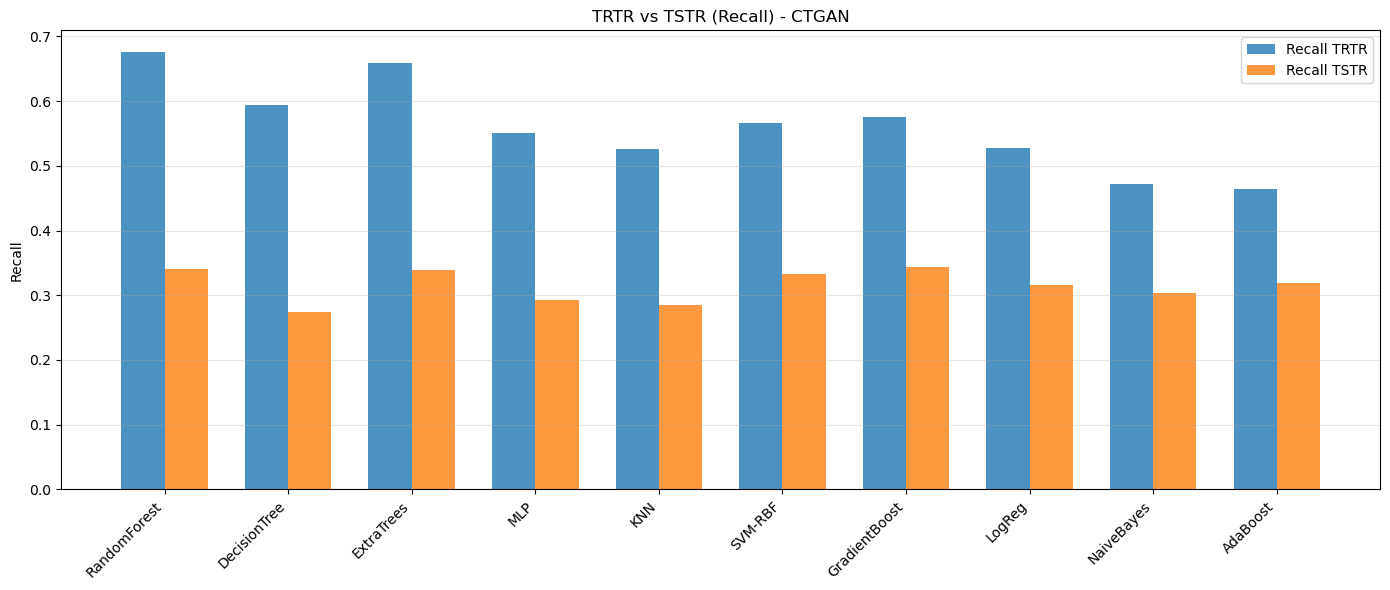

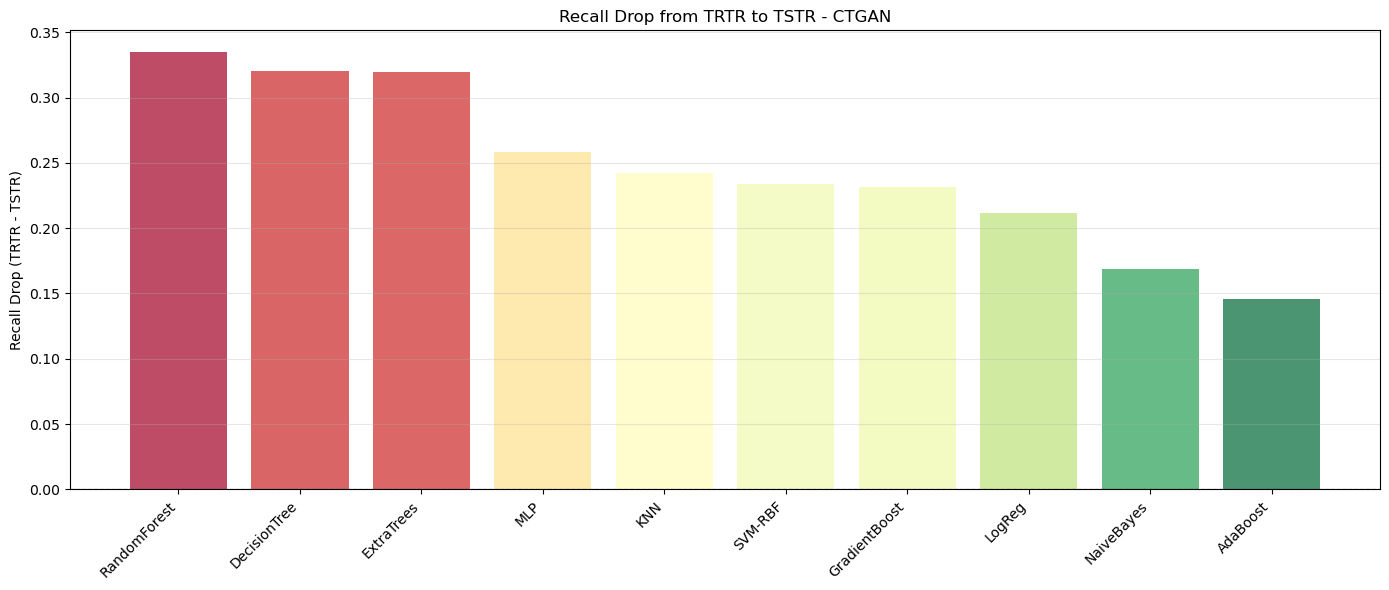


Comparison Graphs for CopulaGAN


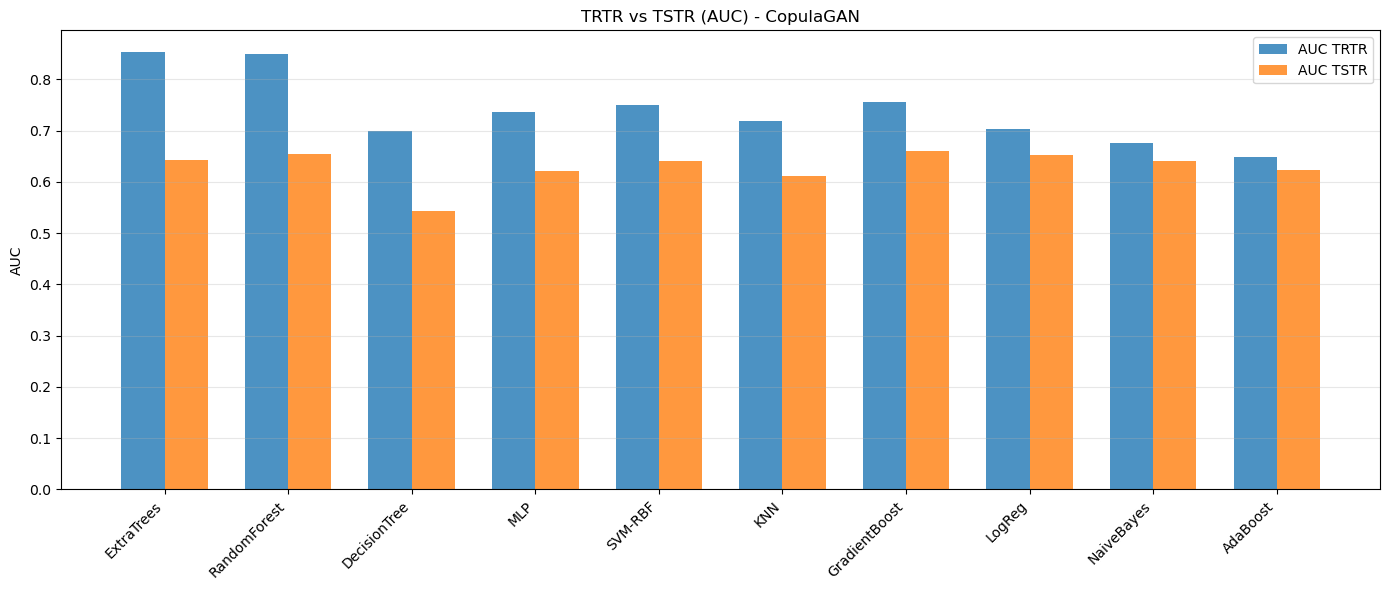

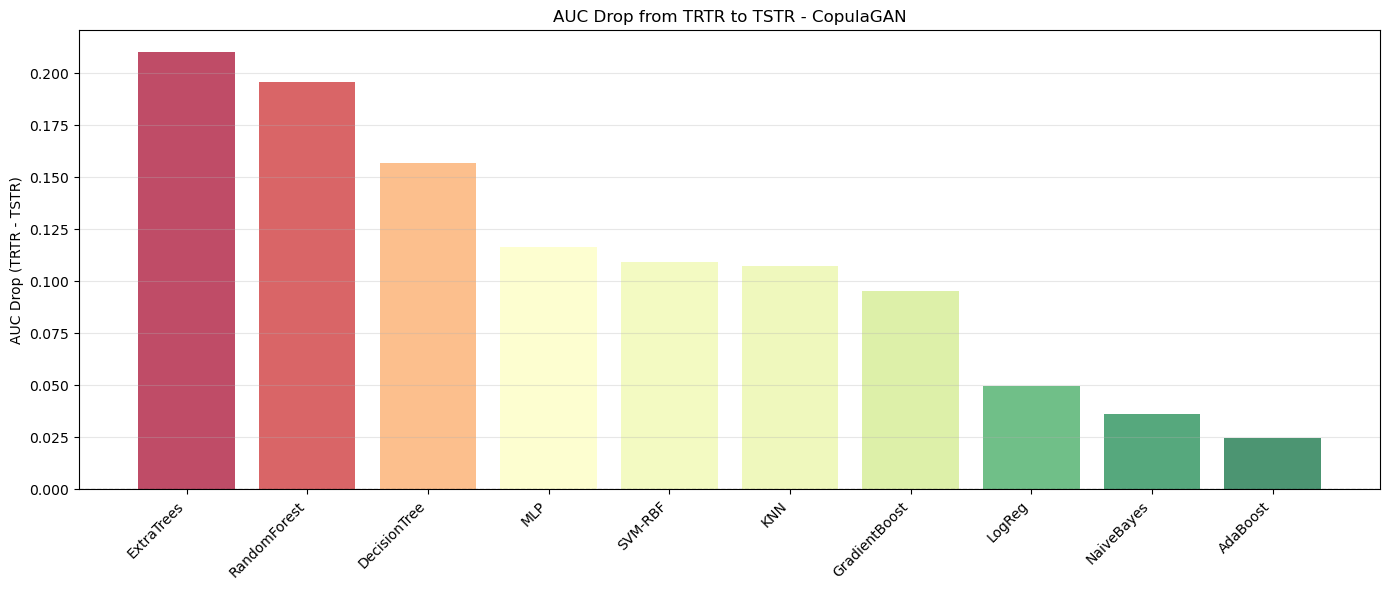

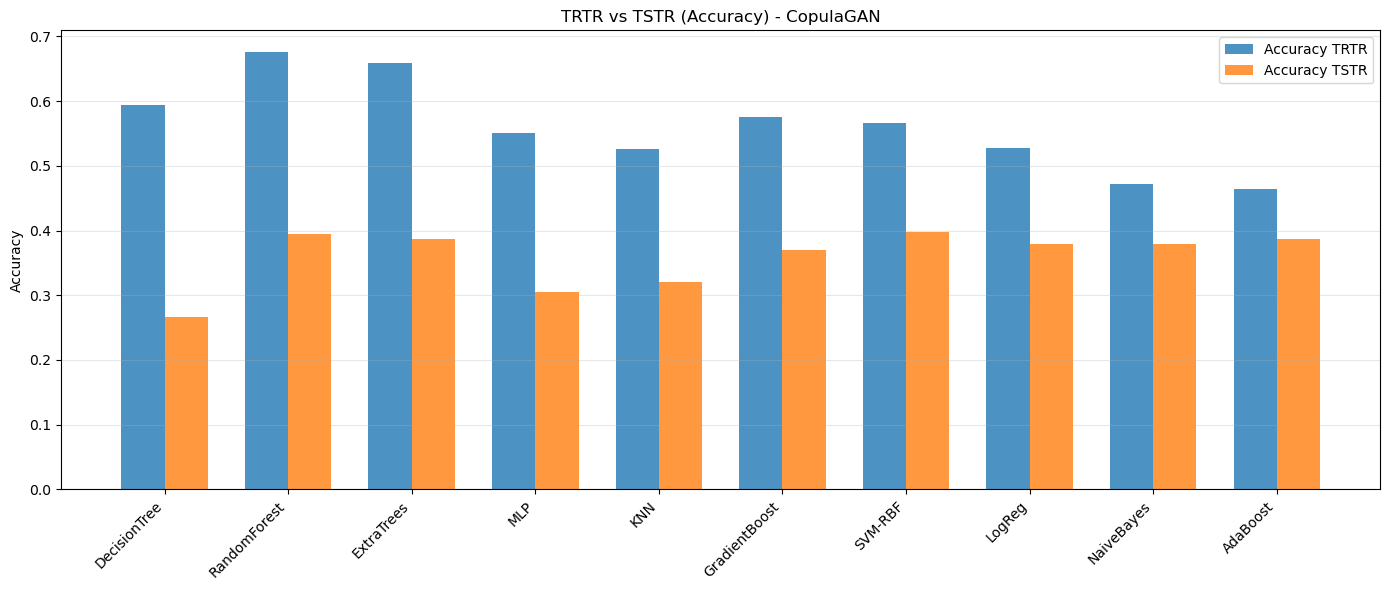

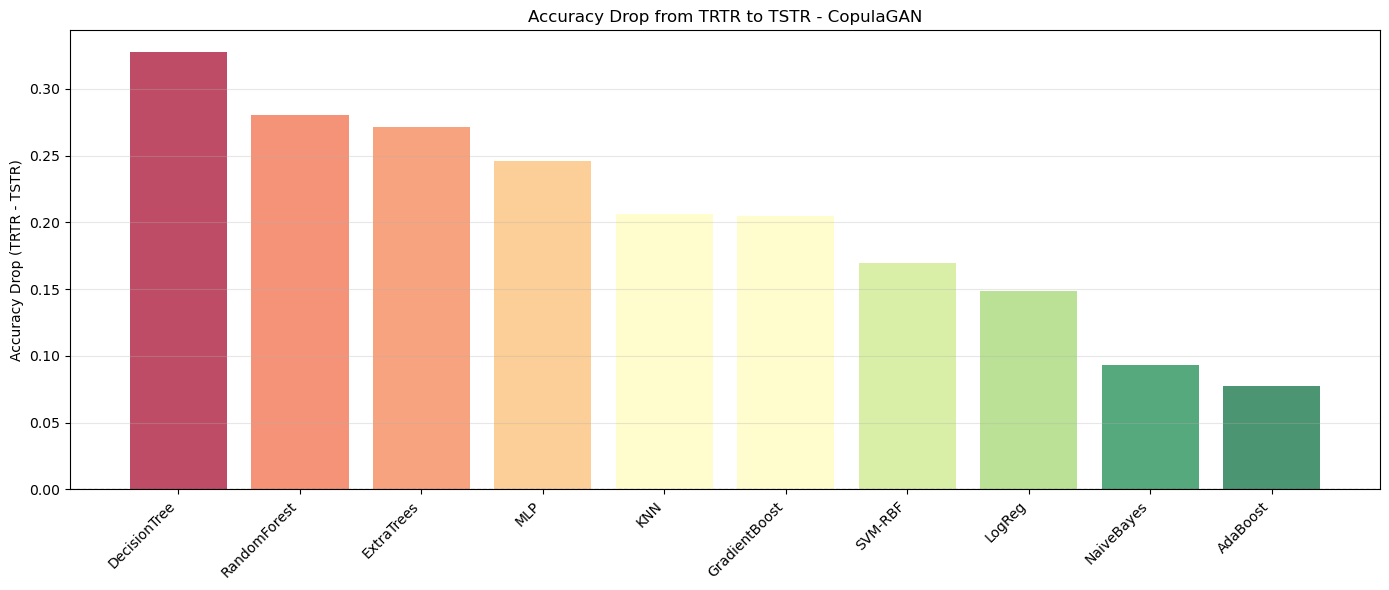

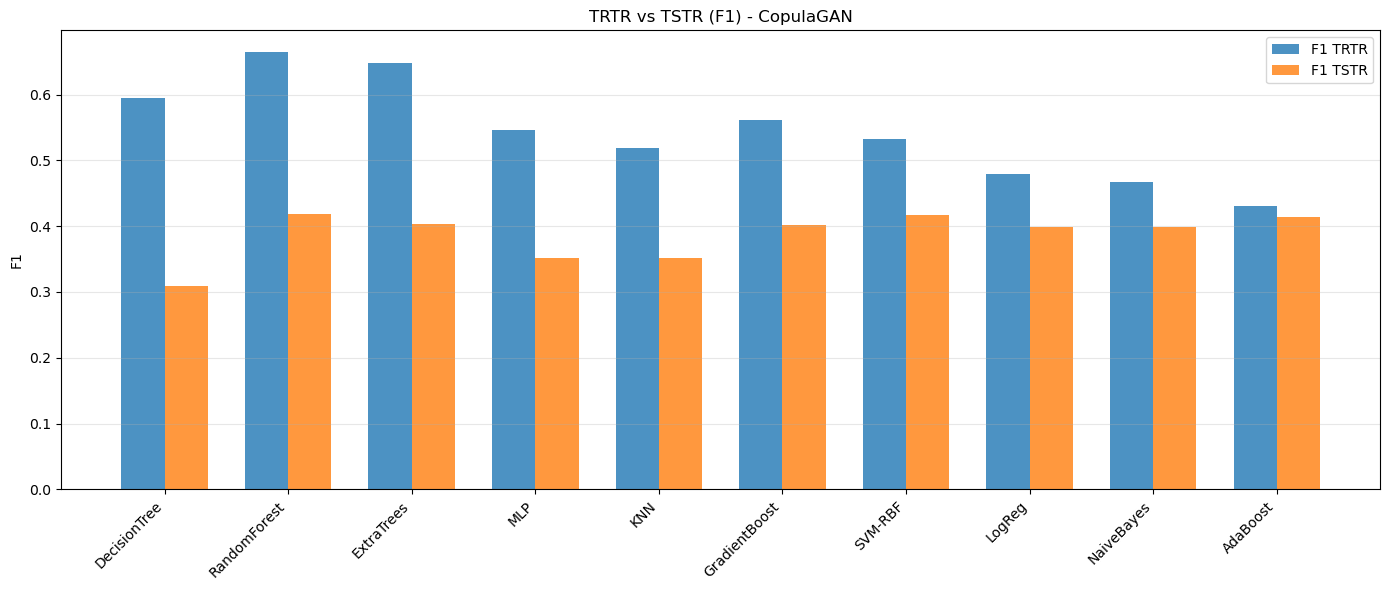

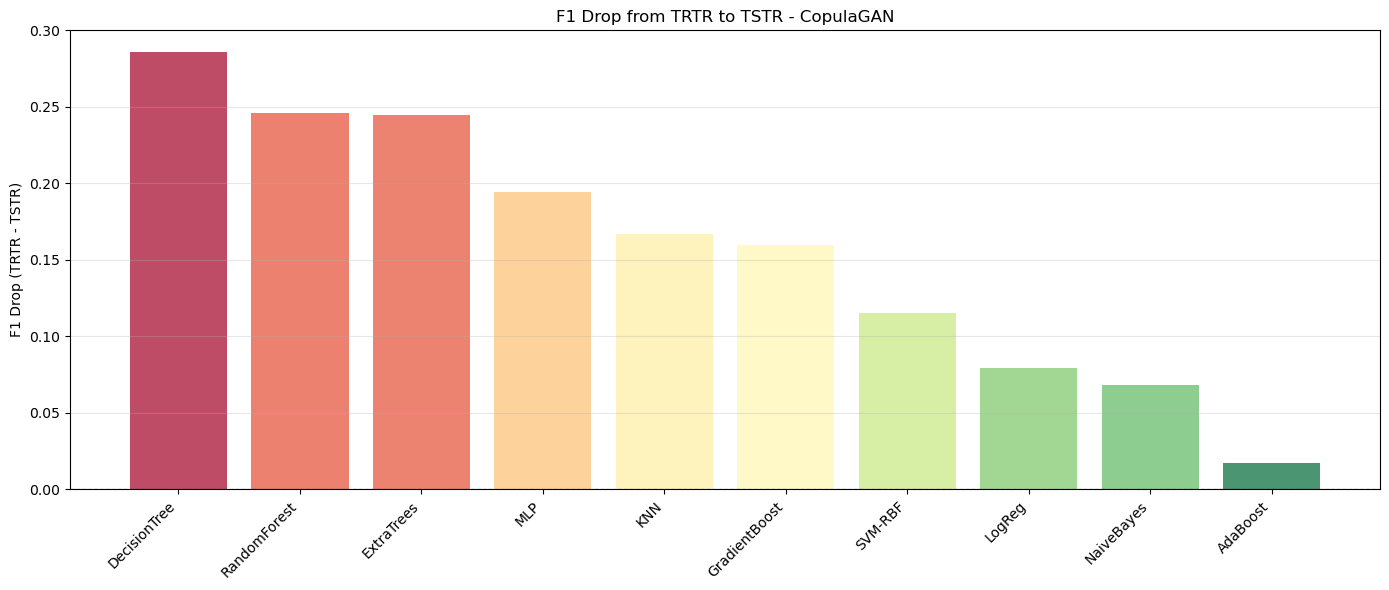

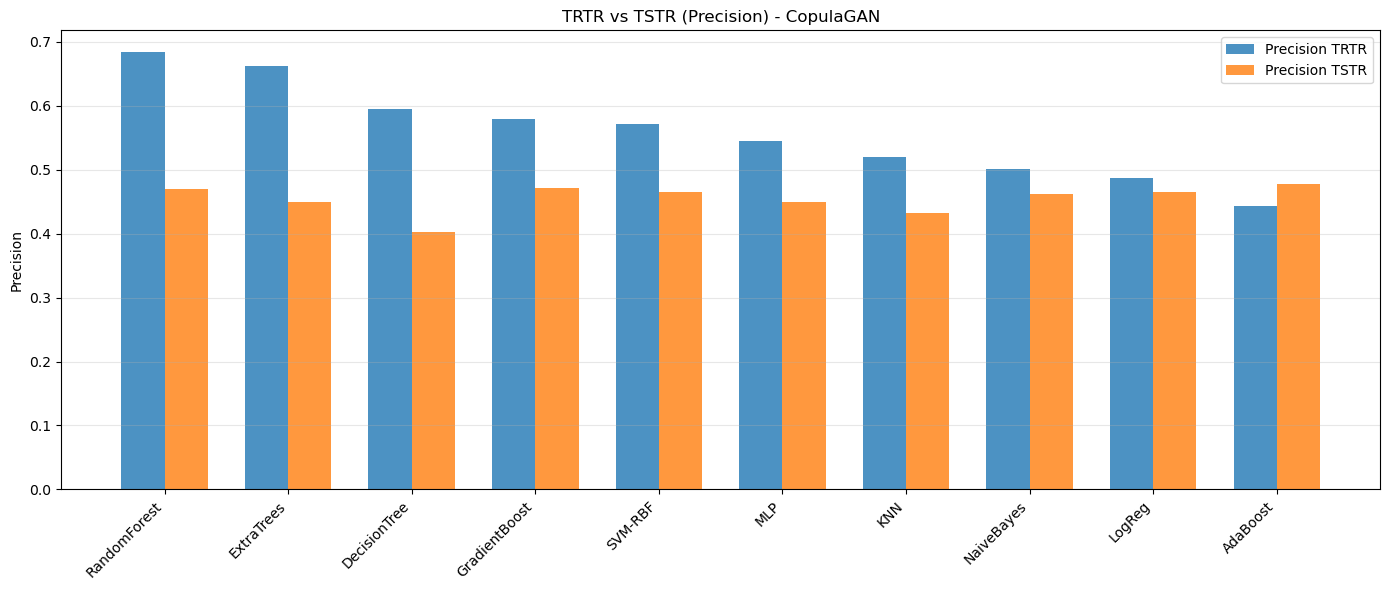

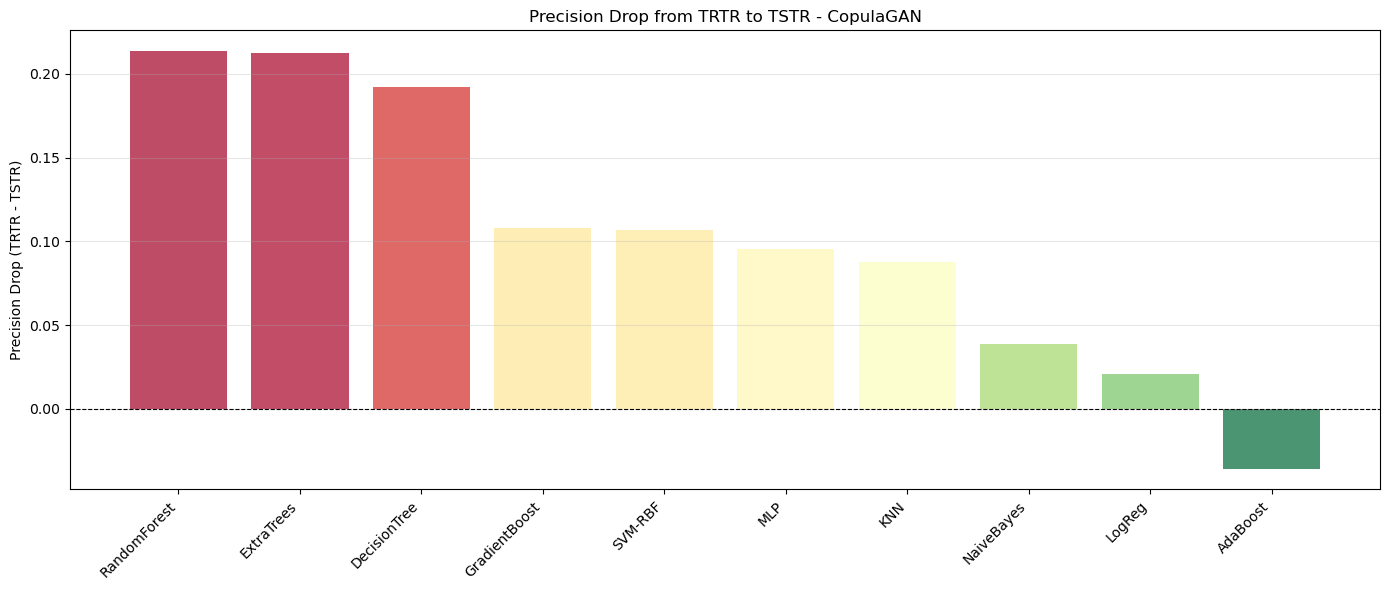

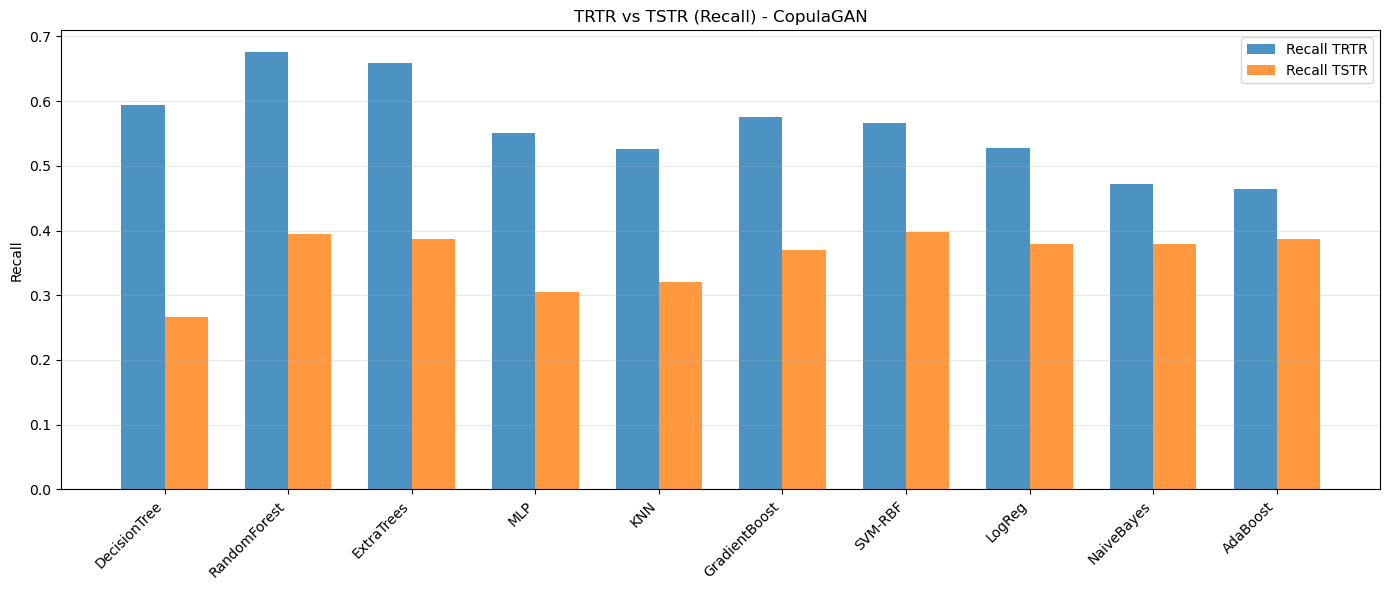

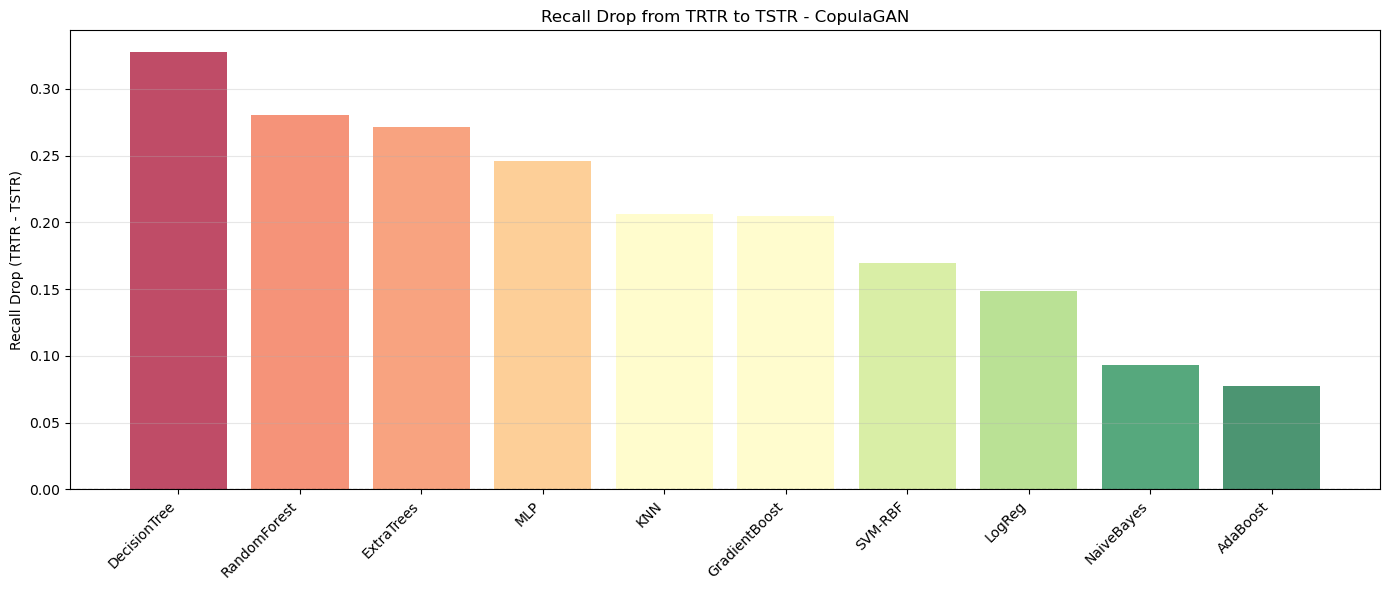


Comparison Graphs for TVAE


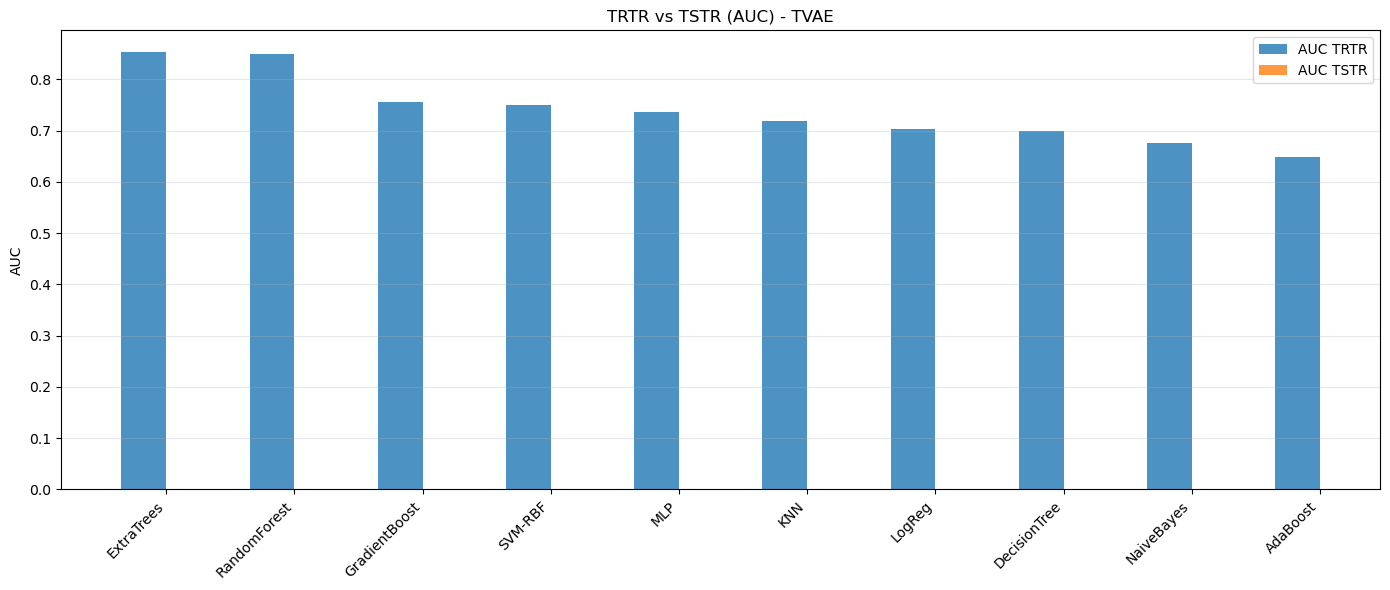

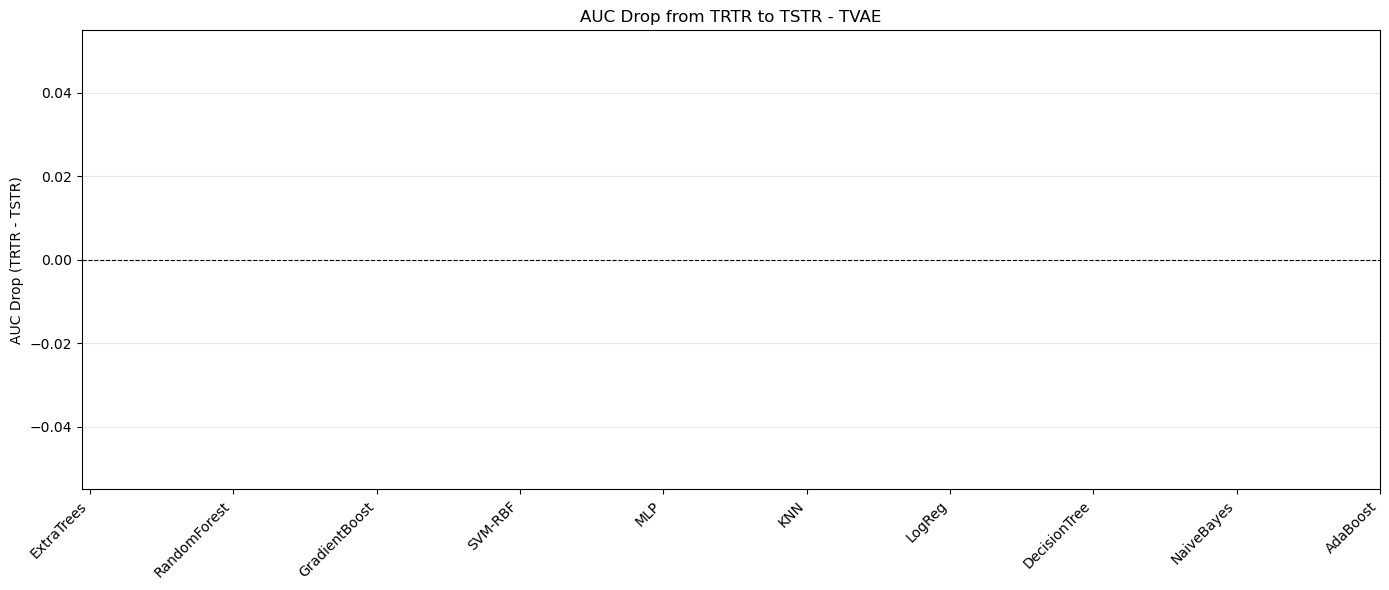

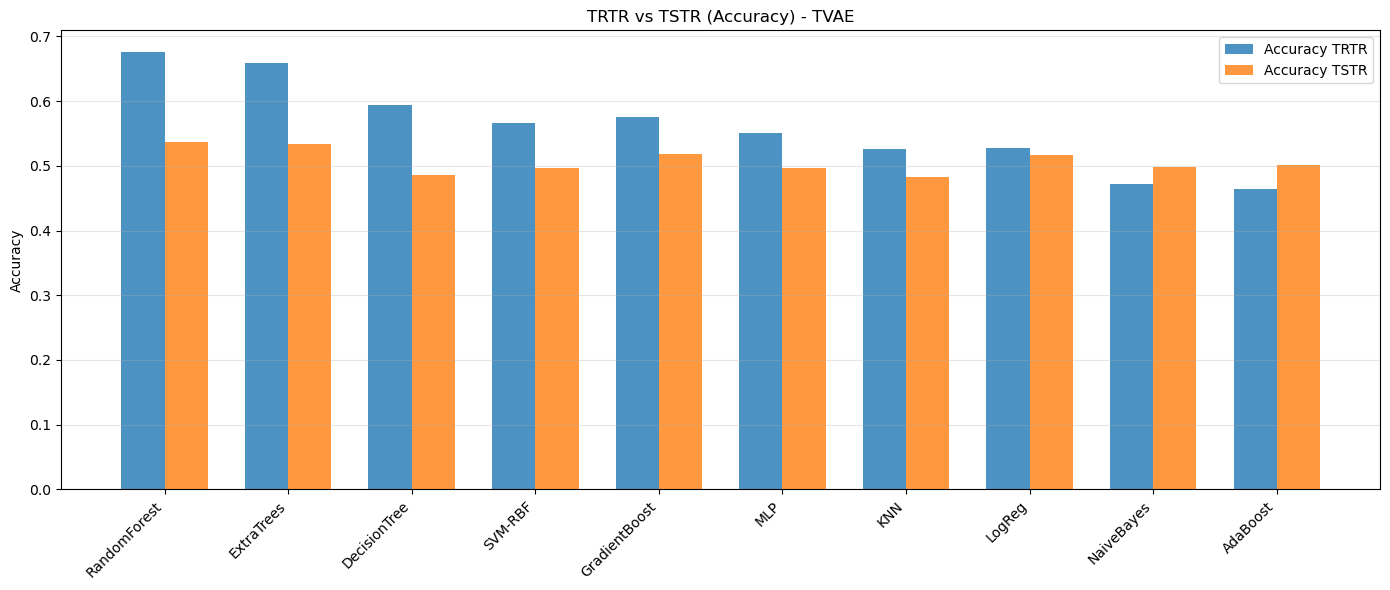

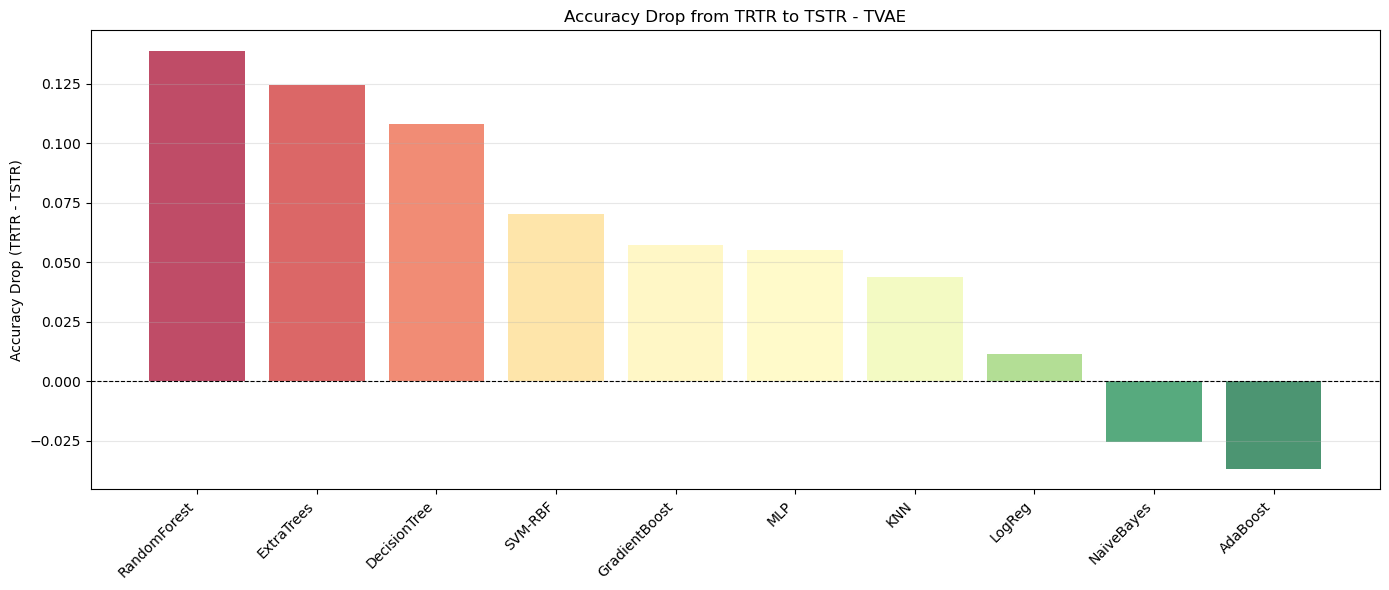

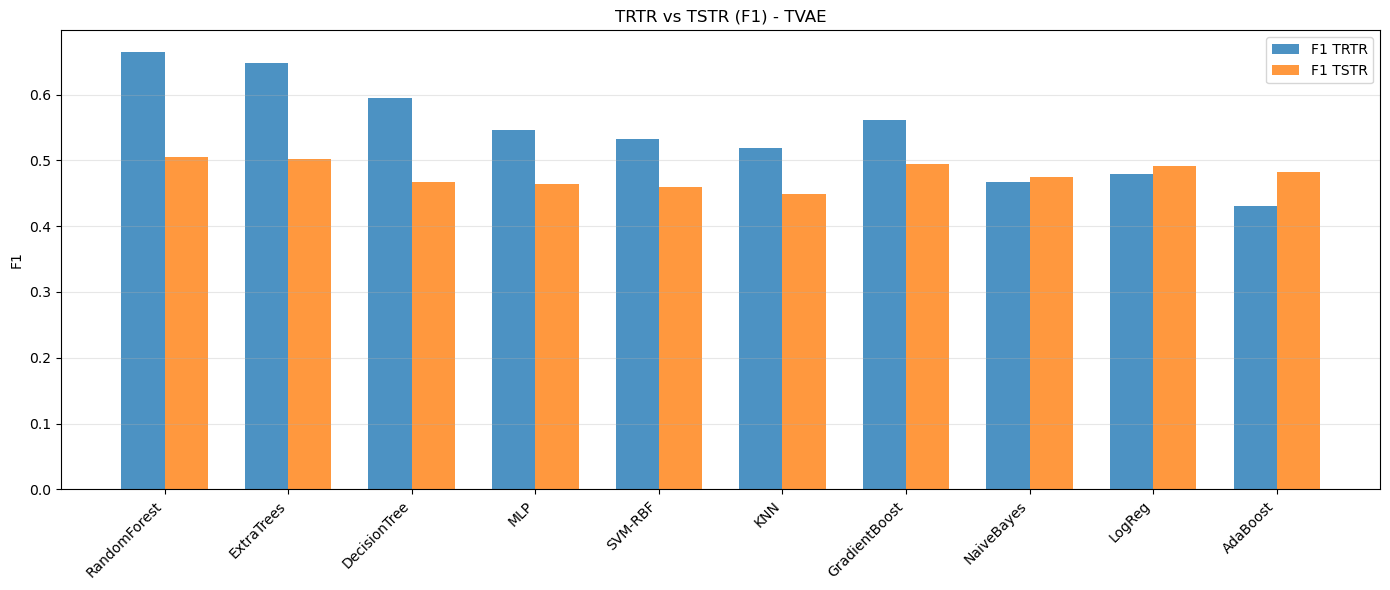

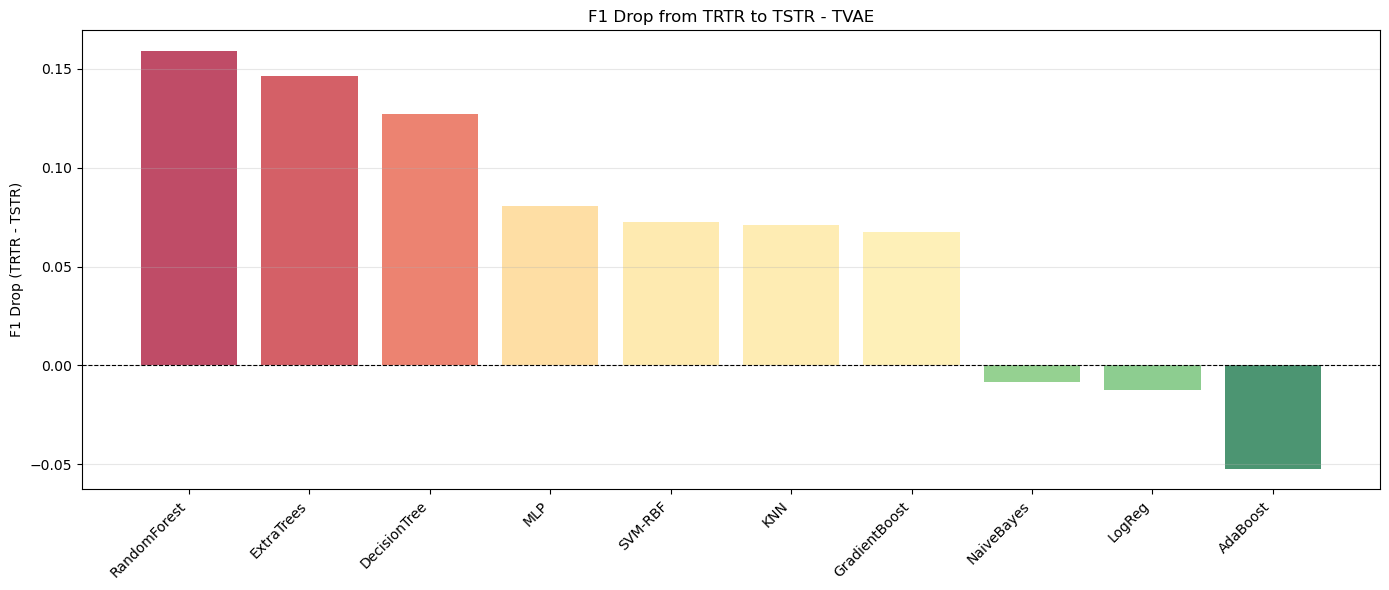

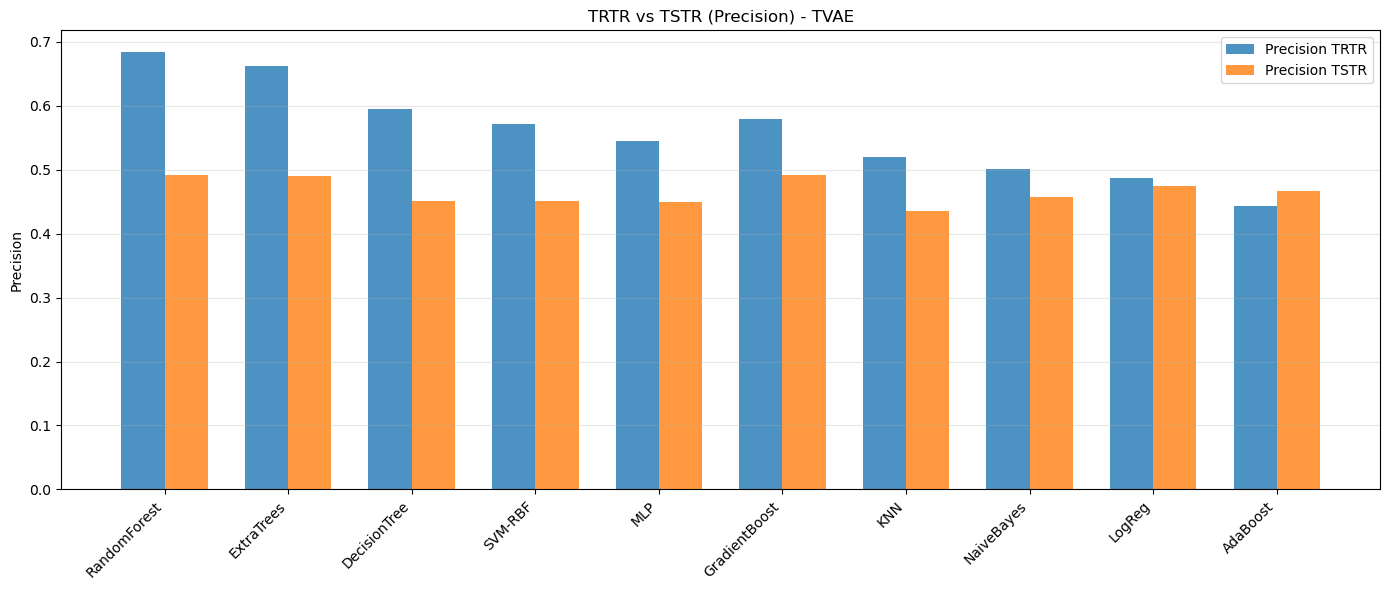

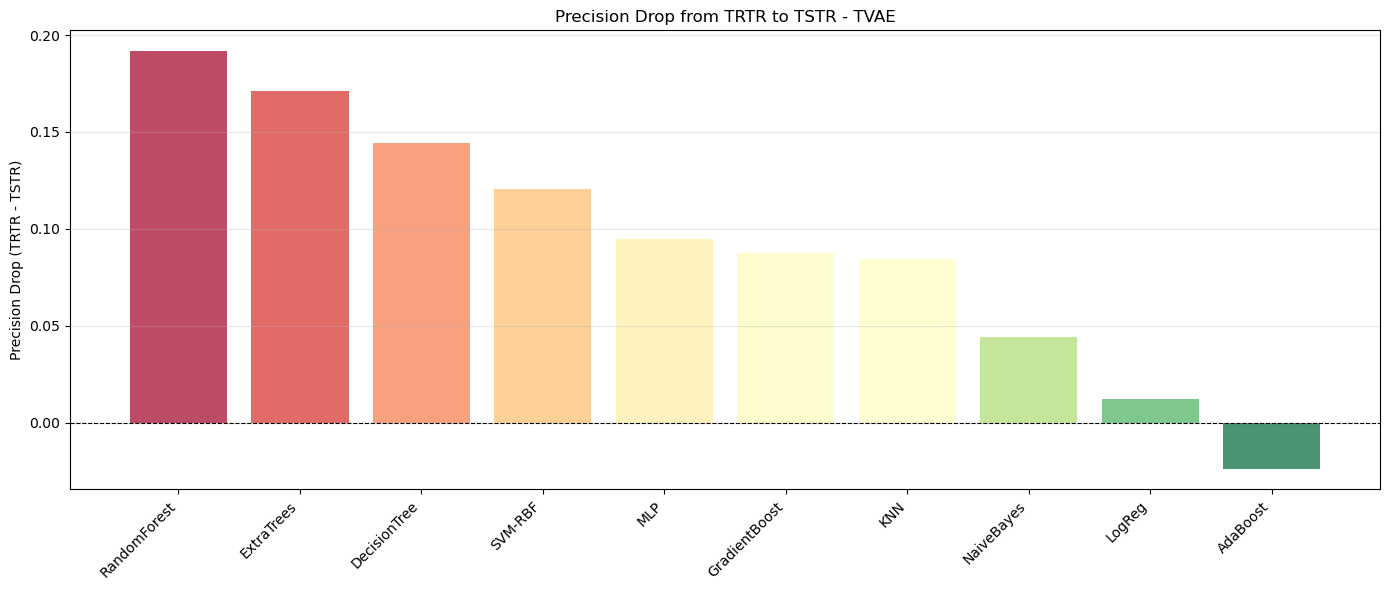

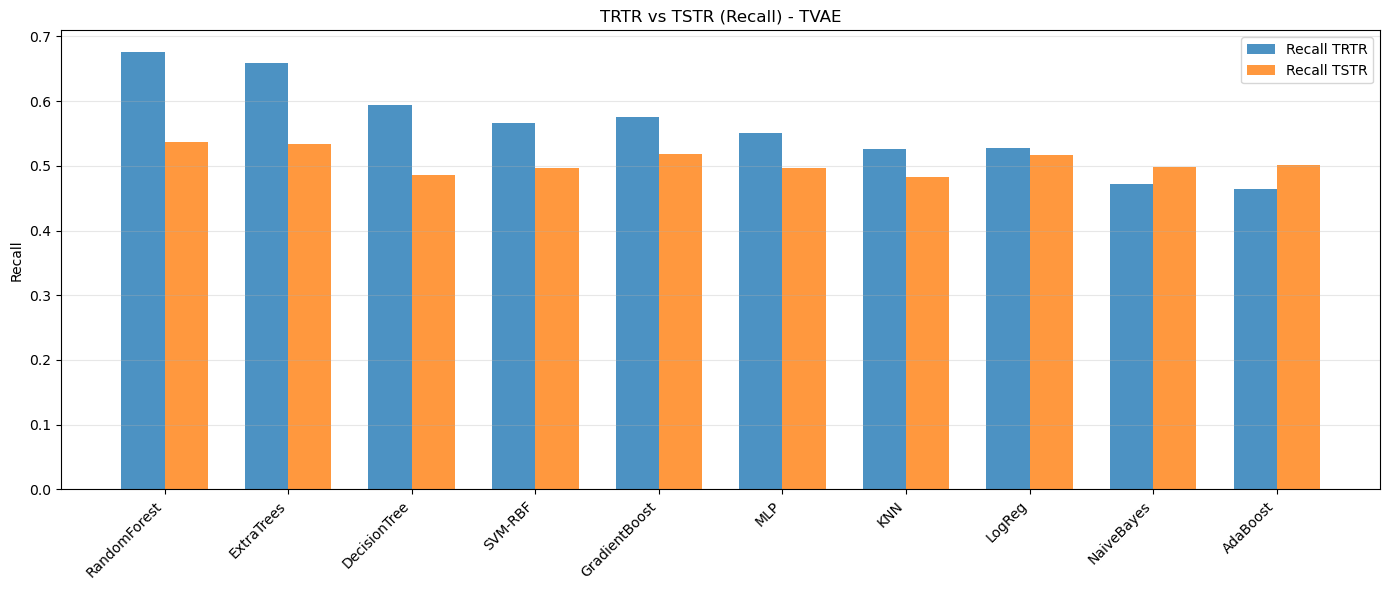

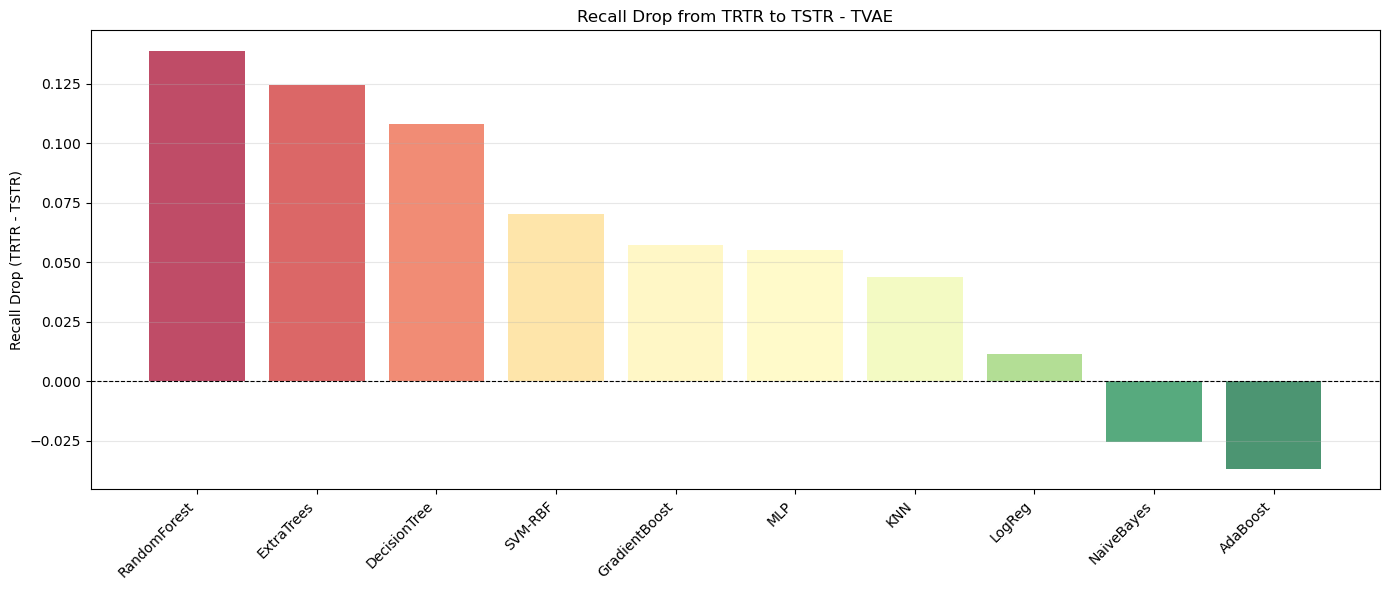


Comparison Graphs for GaussianCopula


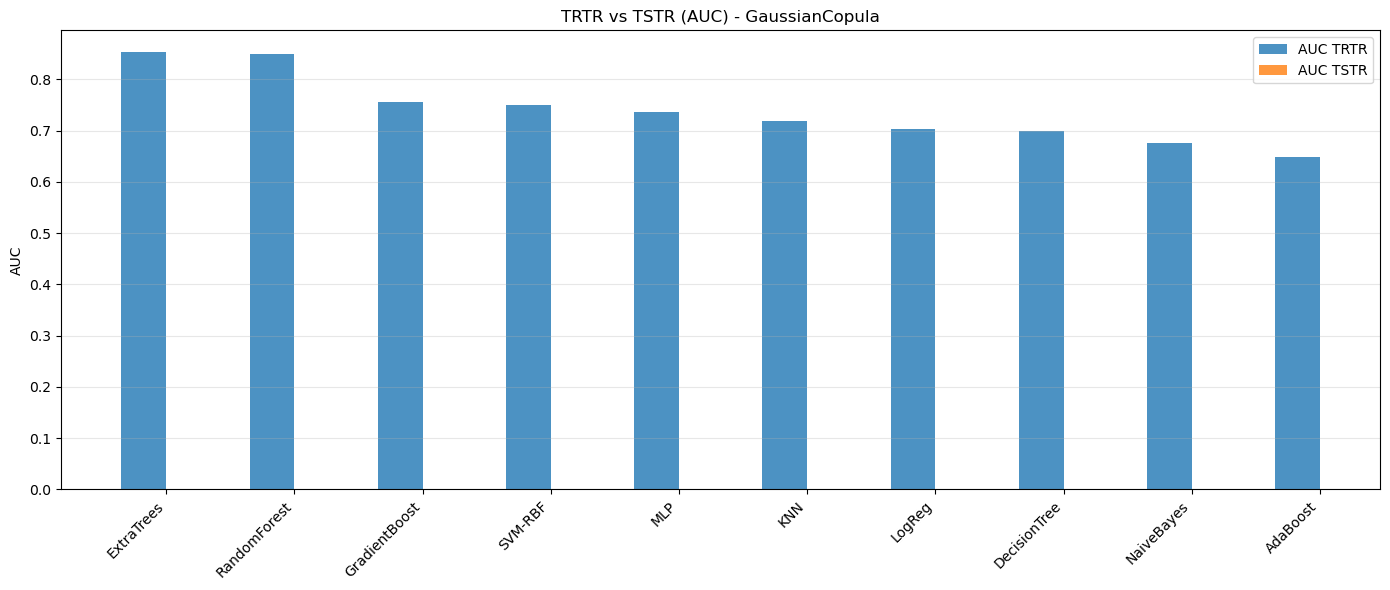

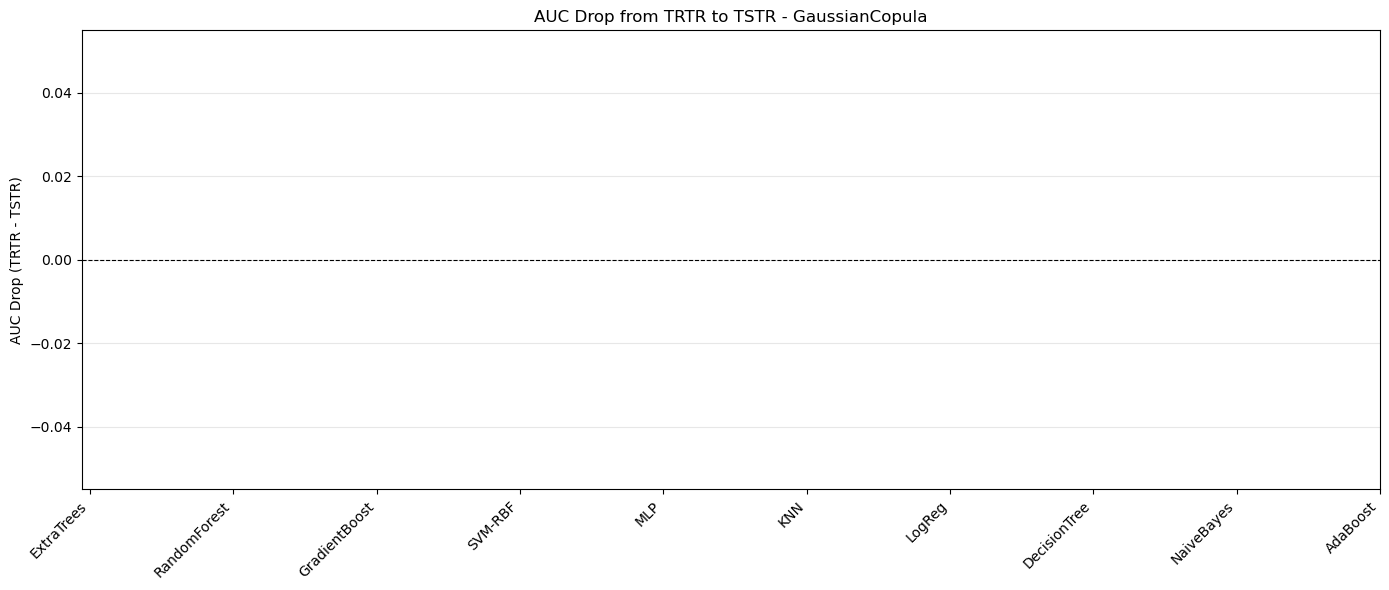

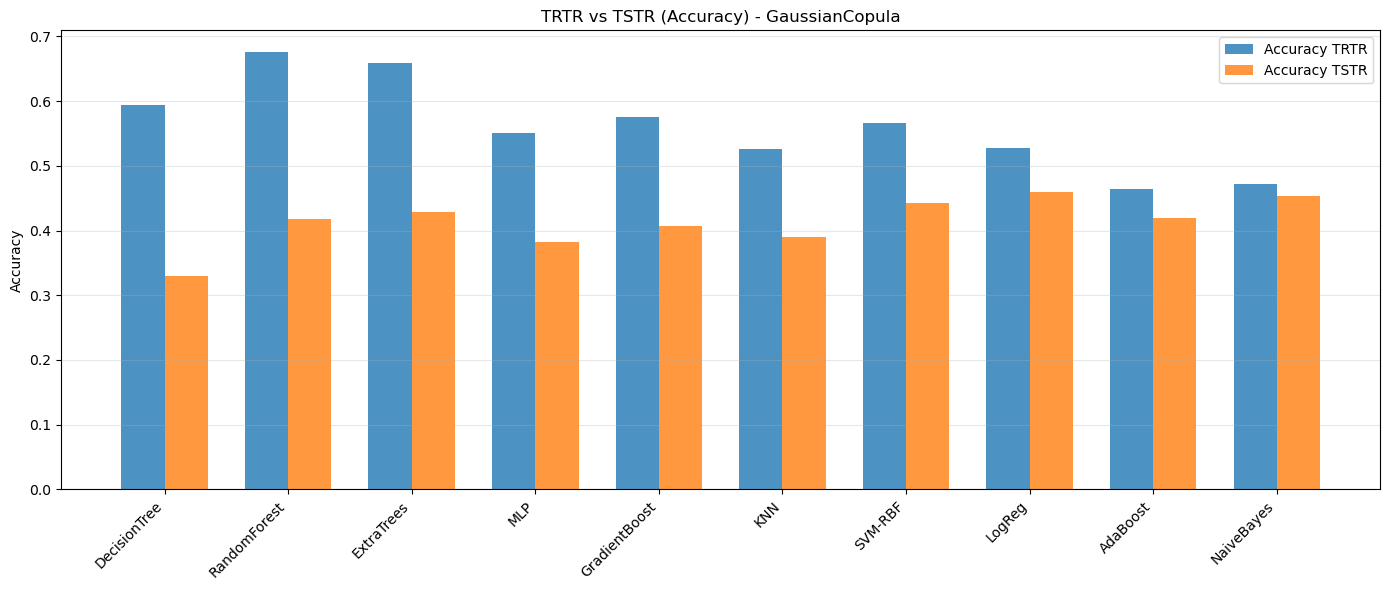

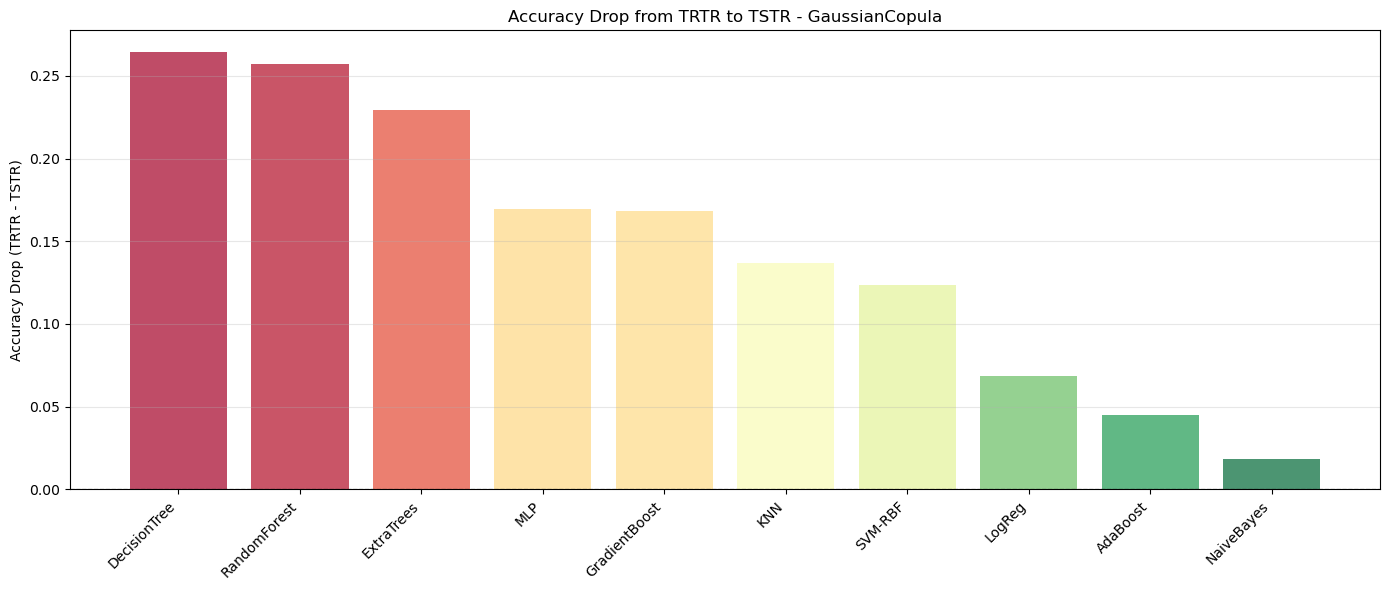

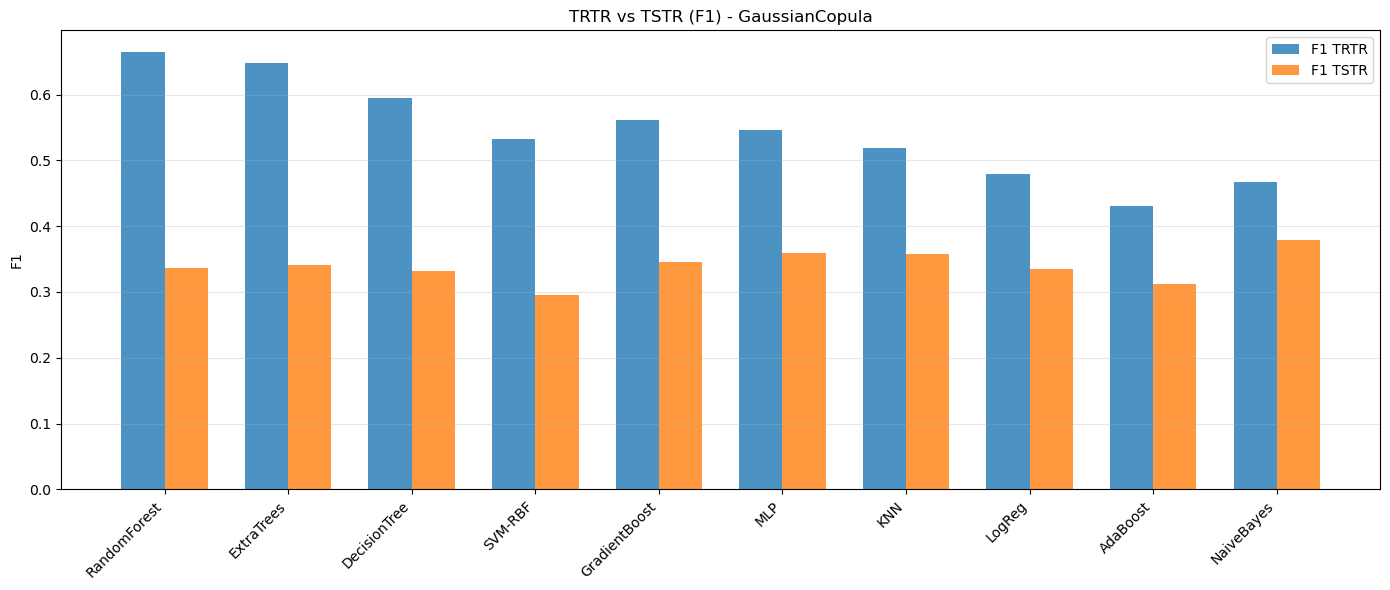

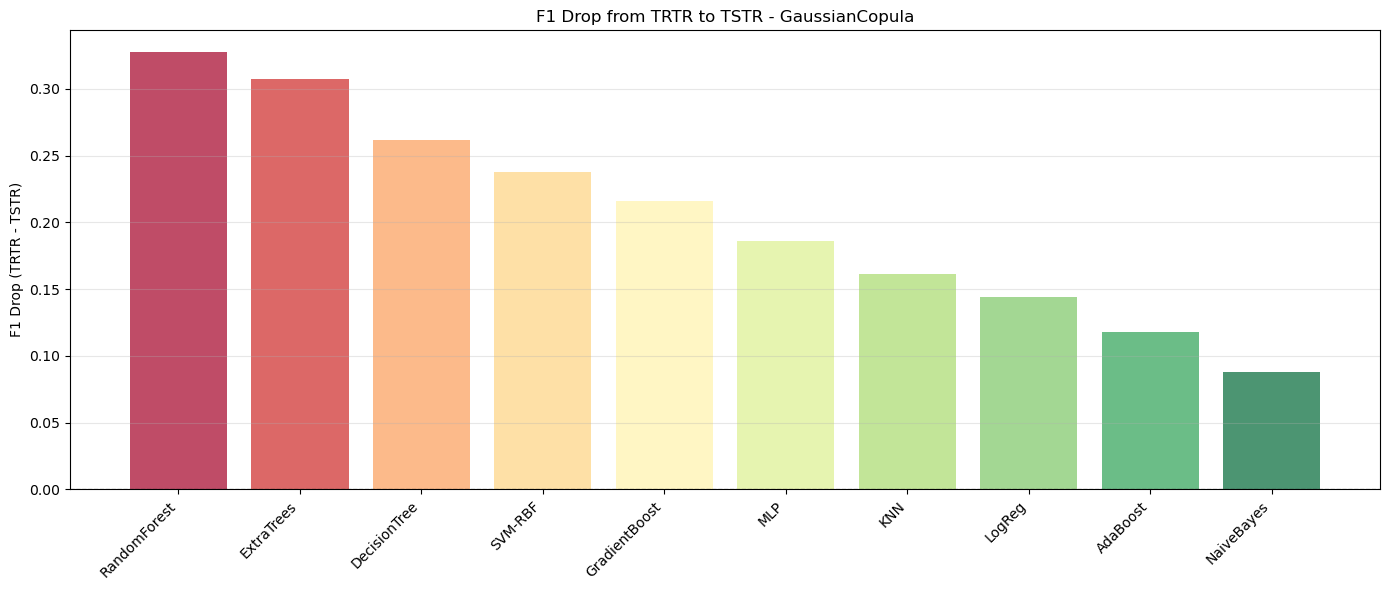

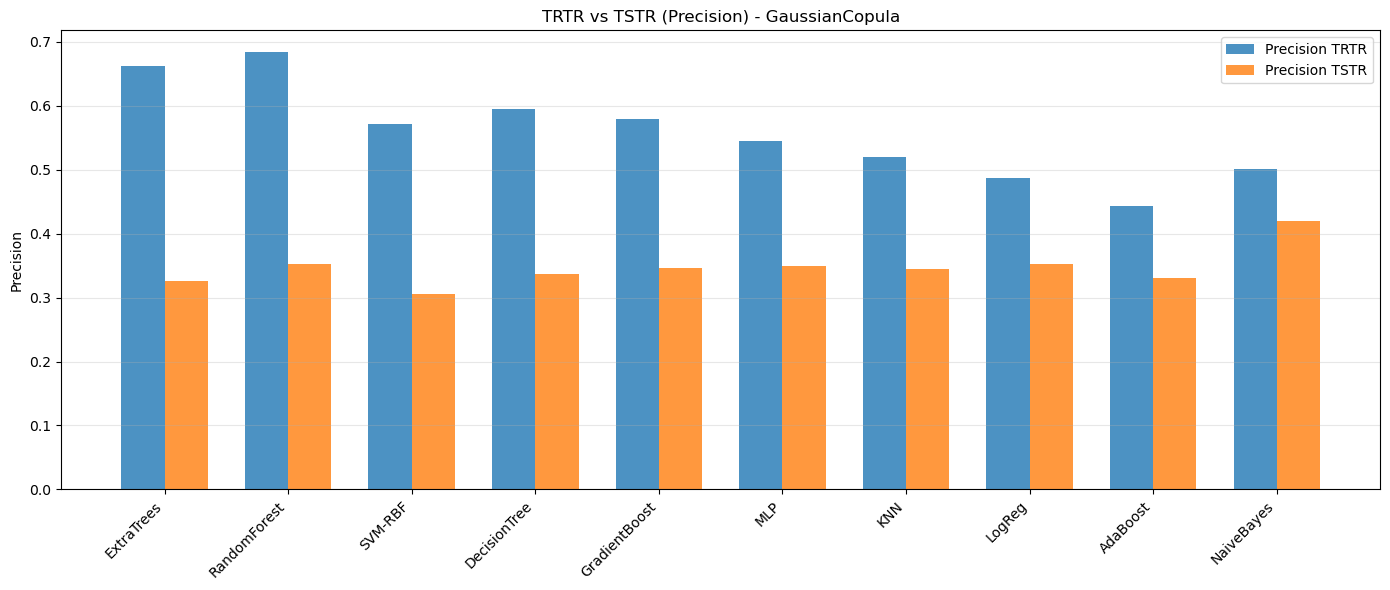

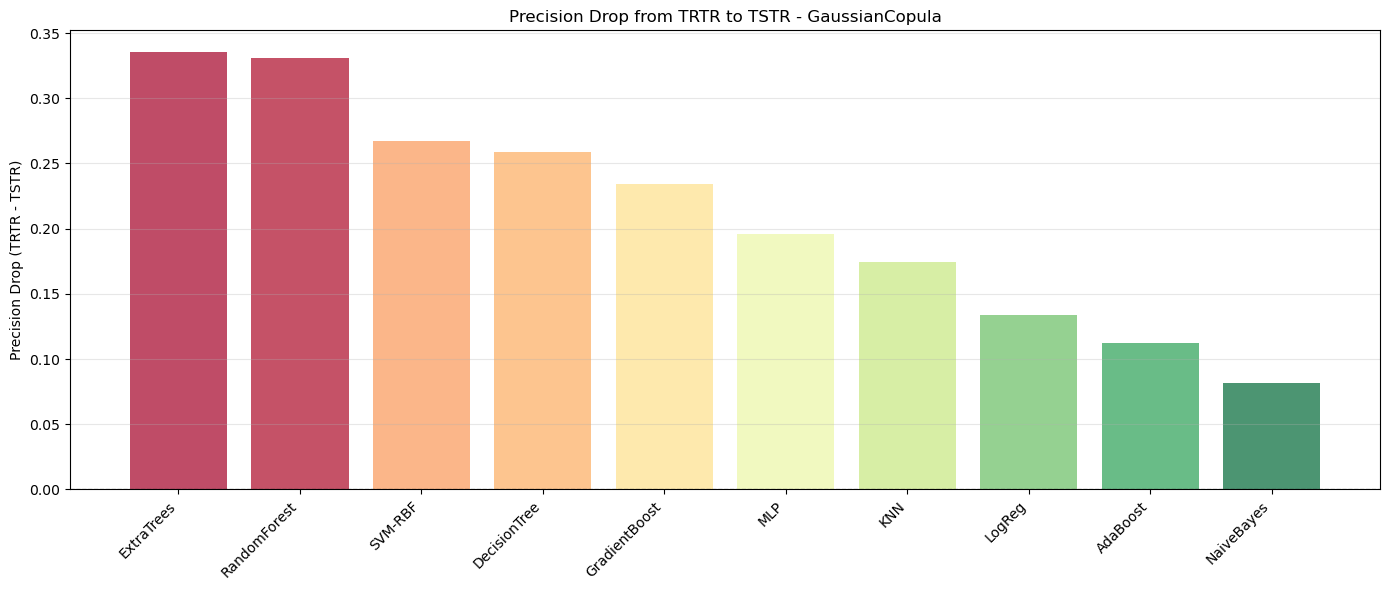

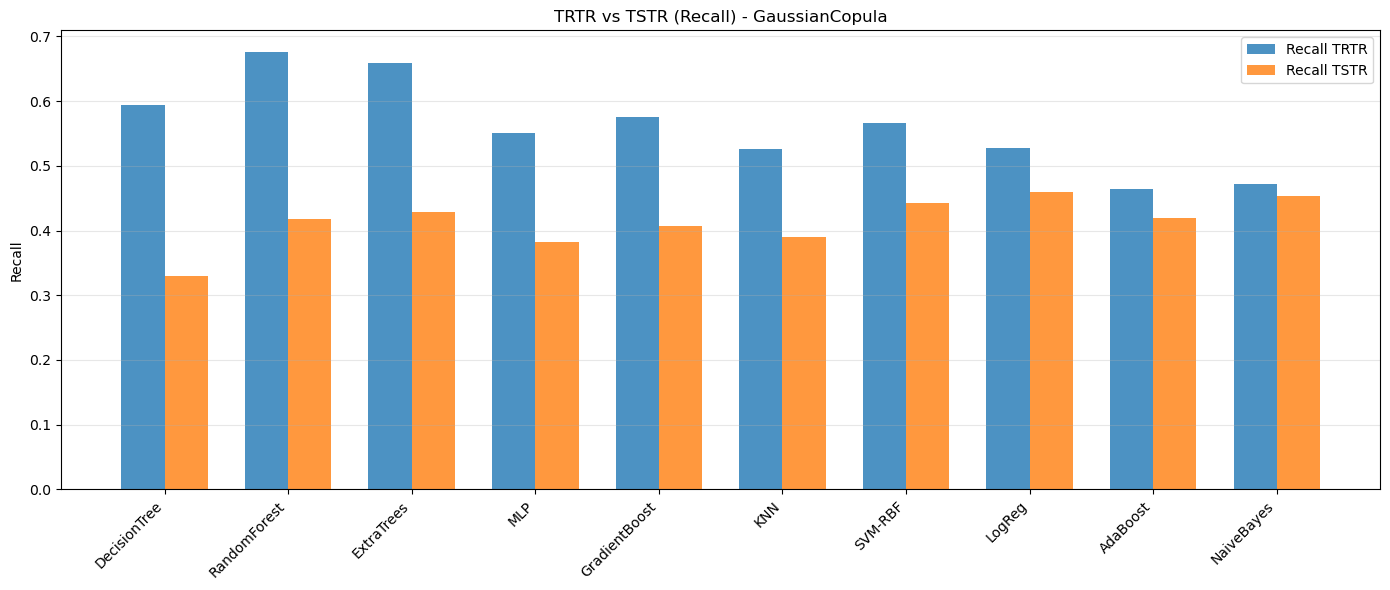

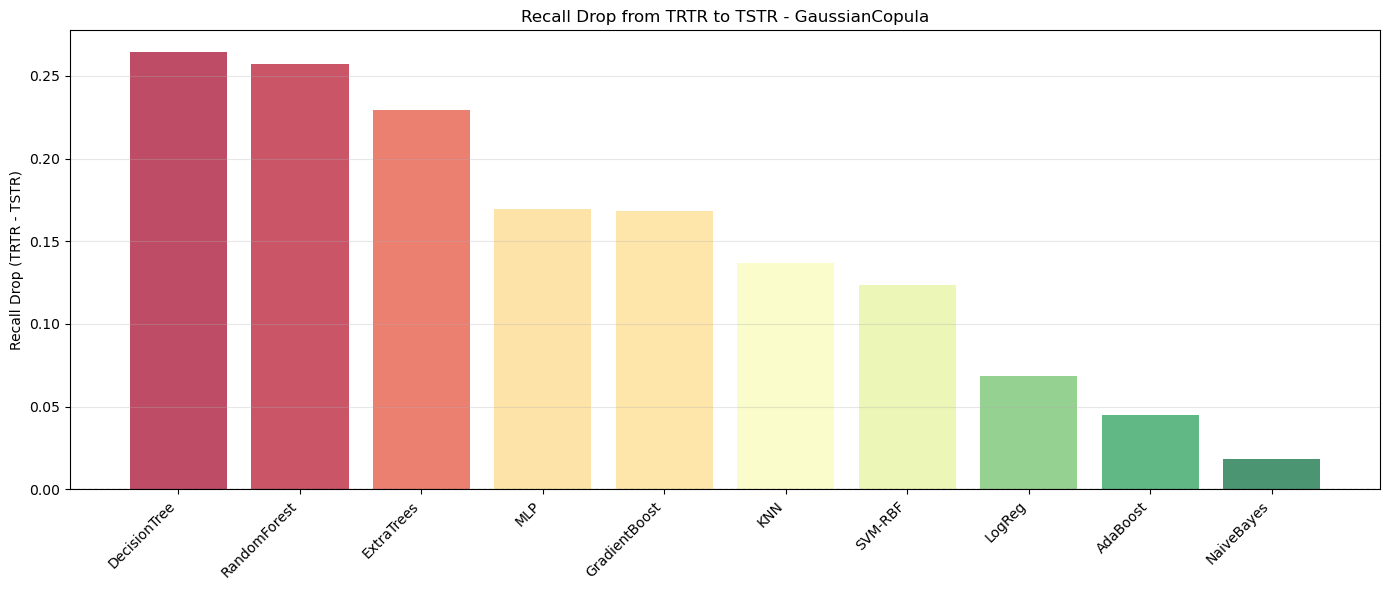

In [12]:
if len(all_results) > 0:
    for model_name, results_df in all_results.items():
        print(f"\n{'='*70}")
        print(f"Comparison Graphs for {model_name}")
        print(f"{'='*70}")
        create_comprehensive_comparison(results_df, model_name=model_name)
else:
    print("No results. Run the synthetic data and evaluation cells first.")

## 5. Fidelity: Column Shapes (KS Complement)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 53.71it/s]|
Column Shapes Score: 81.55%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 299.81it/s]|
Column Pair Trends Score: 83.88%

Overall Score (Average): 82.72%



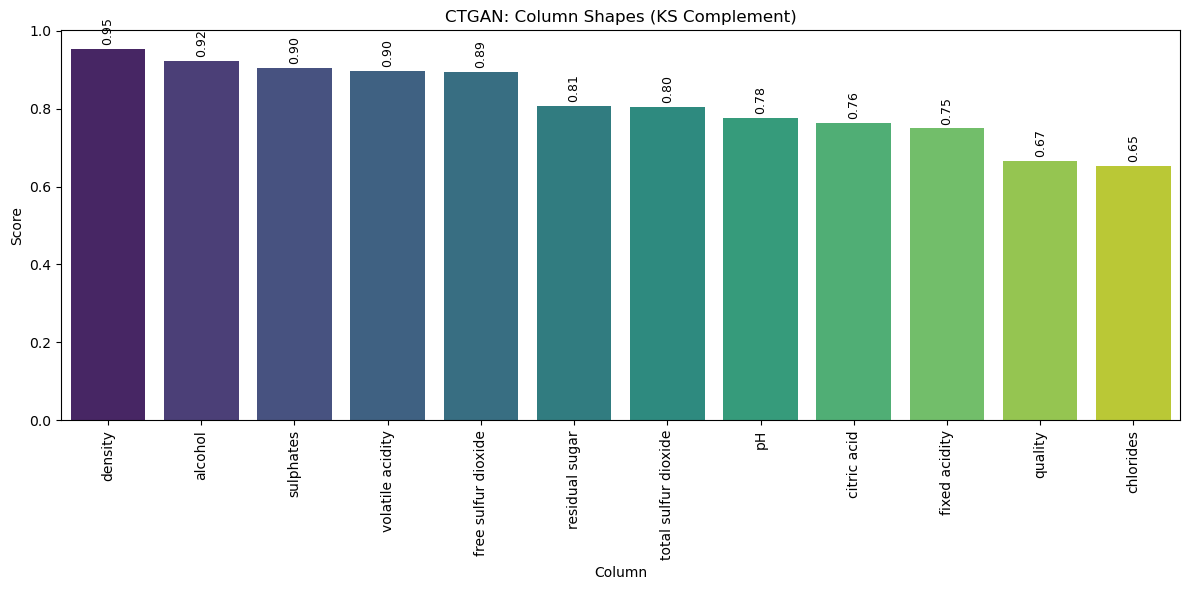

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 91.65it/s]|
Column Shapes Score: 88.38%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 281.82it/s]|
Column Pair Trends Score: 86.45%

Overall Score (Average): 87.41%



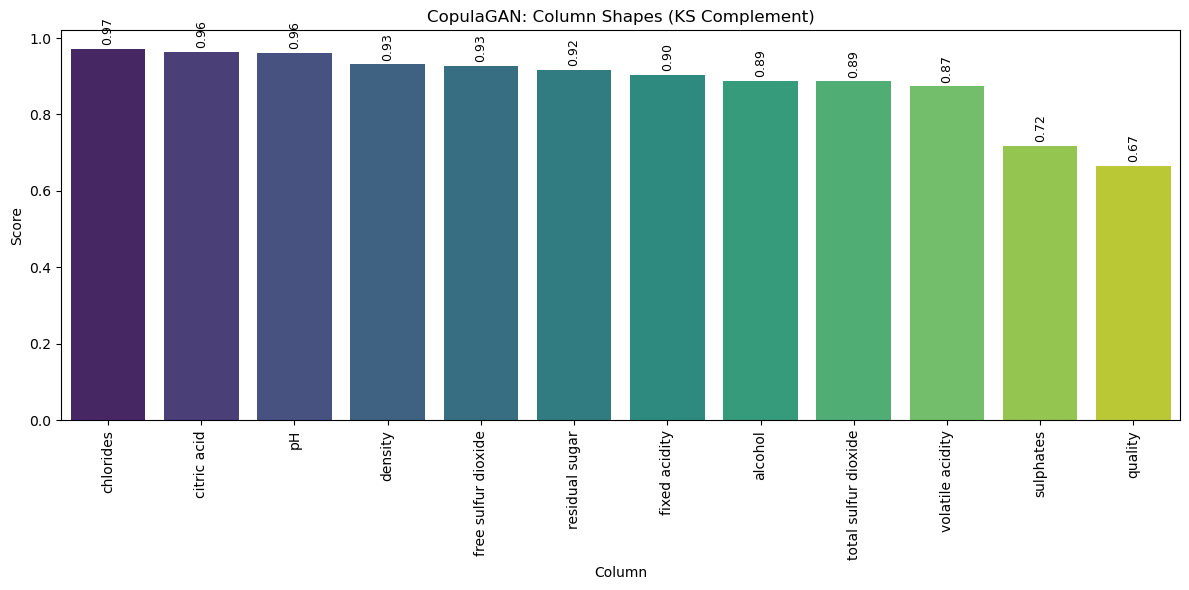

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 96.44it/s]|
Column Shapes Score: 89.56%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 319.43it/s]|
Column Pair Trends Score: 88.63%

Overall Score (Average): 89.09%



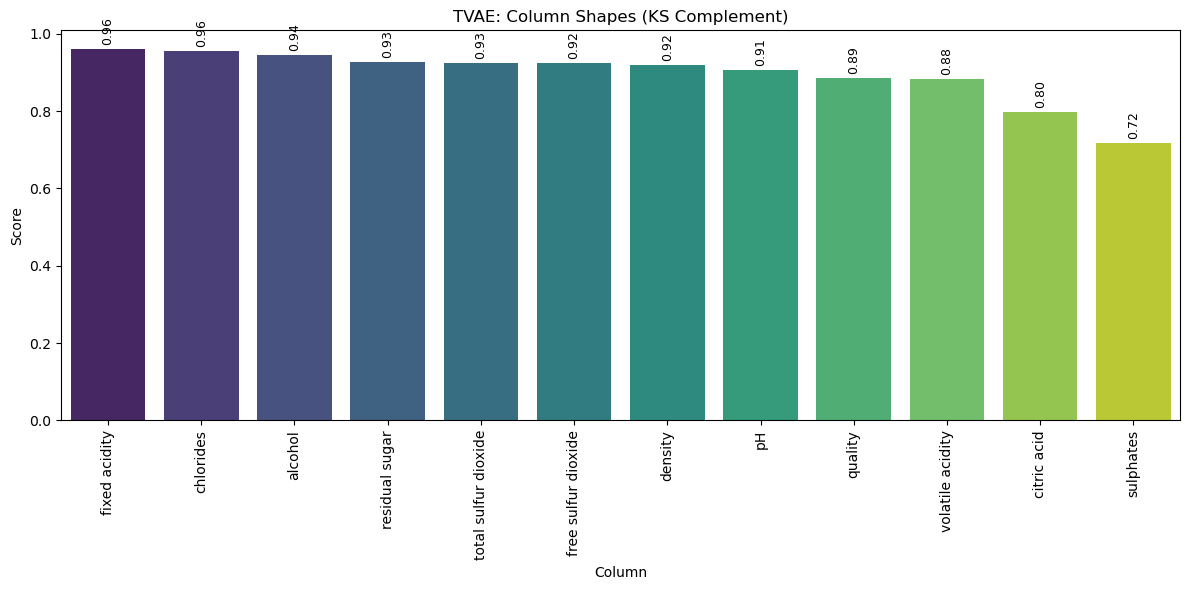

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 175.37it/s]|
Column Shapes Score: 94.84%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 291.75it/s]|
Column Pair Trends Score: 92.69%

Overall Score (Average): 93.77%



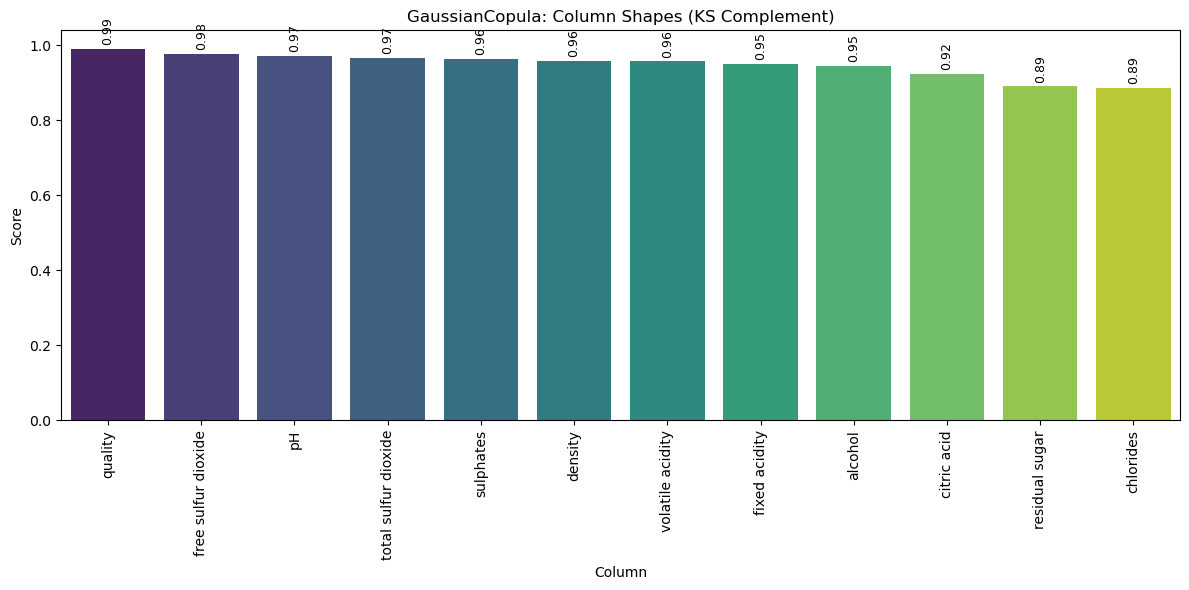

In [13]:
from sdv.evaluation.single_table import QualityReport
import seaborn as sns

synthetic_data_dict = {
    "CTGAN": synthetic_data["CTGAN"],
    "CopulaGAN": synthetic_data["CopulaGAN"],
    "TVAE": synthetic_data["TVAE"],
    "GaussianCopula": synthetic_data["GaussianCopula"]
}

for model_name, synth_df in synthetic_data_dict.items():
    qr = QualityReport()
    qr.generate(real_data=wine_data, synthetic_data=synth_df, metadata=metadata.to_dict())
    details = qr.get_details('Column Shapes')
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Column', y='Score', data=details.sort_values('Score', ascending=False), palette='viridis')
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.01, f"{p.get_height():.2f}", ha='center', va='bottom', fontsize=9, rotation=90)
    plt.title(f'{model_name}: Column Shapes (KS Complement)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## 6. Fidelity: Wasserstein Distance


In [14]:
from scipy.stats import wasserstein_distance

wasserstein_results = {}

for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_scaled = pd.DataFrame(scaler.transform(wine_data[numeric_cols]), columns=numeric_cols)
    synth_scaled = pd.DataFrame(scaler.transform(synth_df[numeric_cols]), columns=numeric_cols)
    wasserstein_scores = []
    for col in numeric_cols:
        r = real_scaled[col].dropna().astype(float)
        s = synth_scaled[col].dropna().astype(float)
        try:
            w_dist = wasserstein_distance(r, s)
        except Exception:
            w_dist = np.nan
        wasserstein_scores.append({"Column": col, "Wasserstein": w_dist})
    wasserstein_results[model_name] = pd.DataFrame(wasserstein_scores).sort_values("Wasserstein")
    print(f"\nWasserstein distances for {model_name}:")
    print(wasserstein_results[model_name])


Wasserstein distances for CTGAN:
                  Column  Wasserstein
7                density     0.091311
1       volatile acidity     0.142178
5    free sulfur dioxide     0.168930
10               alcohol     0.170558
9              sulphates     0.239513
0          fixed acidity     0.379323
6   total sulfur dioxide     0.386681
3         residual sugar     0.401854
4              chlorides     0.483497
8                     pH     0.587630
2            citric acid     0.620244
11               quality     0.779787

Wasserstein distances for CopulaGAN:
                  Column  Wasserstein
4              chlorides     0.038639
5    free sulfur dioxide     0.085205
8                     pH     0.087168
2            citric acid     0.104318
7                density     0.122232
0          fixed acidity     0.125910
3         residual sugar     0.136877
1       volatile acidity     0.153723
6   total sulfur dioxide     0.165228
10               alcohol     0.220878
9              s

## 7. Fidelity: JS Divergence


In [15]:
from scipy.spatial.distance import jensenshannon

def compute_js_divergence(real_vals, synth_vals, bins=30):
    real_vals = np.asarray(real_vals)[~np.isnan(np.asarray(real_vals))]
    synth_vals = np.asarray(synth_vals)[~np.isnan(np.asarray(synth_vals))]
    if len(real_vals) == 0 or len(synth_vals) == 0:
        return np.nan
    low, high = min(real_vals.min(), synth_vals.min()), max(real_vals.max(), synth_vals.max())
    if low == high:
        return 0.0
    p_hist, bin_edges = np.histogram(real_vals, bins=bins, range=(low, high), density=True)
    q_hist, _ = np.histogram(synth_vals, bins=bin_edges, density=True)
    p = (p_hist + 1e-12); p /= p.sum()
    q = (q_hist + 1e-12); q /= q.sum()
    return jensenshannon(p, q, base=2) ** 2

js_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_scaled = pd.DataFrame(scaler.transform(wine_data[numeric_cols]), columns=numeric_cols)
    synth_scaled = pd.DataFrame(scaler.transform(synth_df[numeric_cols]), columns=numeric_cols)
    js_scores = [{"Column": col, "JS_Divergence": compute_js_divergence(real_scaled[col], synth_scaled[col])} for col in numeric_cols]
    js_results[model_name] = pd.DataFrame(js_scores).sort_values("JS_Divergence")
    print(f"\nJS Divergence for {model_name}:")
    print(js_results[model_name])


JS Divergence for CTGAN:
                  Column  JS_Divergence
7                density       0.008744
5    free sulfur dioxide       0.013156
1       volatile acidity       0.016947
10               alcohol       0.021436
9              sulphates       0.025349
3         residual sugar       0.030993
6   total sulfur dioxide       0.035432
0          fixed acidity       0.054134
8                     pH       0.064811
2            citric acid       0.071767
4              chlorides       0.124627
11               quality       0.136788

JS Divergence for CopulaGAN:
                  Column  JS_Divergence
4              chlorides       0.004729
3         residual sugar       0.005935
8                     pH       0.007895
5    free sulfur dioxide       0.008245
2            citric acid       0.012781
6   total sulfur dioxide       0.017302
0          fixed acidity       0.017762
7                density       0.018897
10               alcohol       0.022864
1       volatile acidity

## 8. Fidelity: Gower Distance

Gower distance measures dissimilarity between real and synthetic samples (handles mixed numeric columns). We report mean Gower distance between datasets (sampled for speed).

In [17]:
# Gower distance (numeric columns only; normalized by range)
def gower_distance_numeric(real_df, synth_df, numeric_cols, n_sample=500):
    """Mean pairwise Gower-like distance: for each real point, mean normalized L1 to nearest synth (or mean over sample)."""
    from sklearn.neighbors import NearestNeighbors
    real = real_df[numeric_cols].dropna()
    synth = synth_df[numeric_cols].dropna()
    n_r = min(n_sample, len(real))
    n_s = min(n_sample, len(synth))
    real_s = real.sample(n_r, random_state=42)
    synth_s = synth.sample(n_s, random_state=42)
    mins = real_s.min()
    maxs = real_s.max()
    rng = (maxs - mins).replace(0, 1)
    real_n = (real_s - mins) / rng
    synth_n = (synth_s - mins) / rng
    nn = NearestNeighbors(n_neighbors=1, metric='manhattan').fit(synth_n)
    dists, _ = nn.kneighbors(real_n)
    return float(np.mean(dists))

gower_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    gower_results[model_name] = gower_distance_numeric(wine_data, synth_df, numeric_cols)
    print(f"{model_name}: mean Gower distance = {gower_results[model_name]:.4f}")
print("\nGower (lower is better):", gower_results)

CTGAN: mean Gower distance = 0.9389
CopulaGAN: mean Gower distance = 0.8751
TVAE: mean Gower distance = 0.7411
GaussianCopula: mean Gower distance = 0.7967

Gower (lower is better): {'CTGAN': 0.9389464308147736, 'CopulaGAN': 0.8750705364489649, 'TVAE': 0.741084484858754, 'GaussianCopula': 0.7967086972370687}


## 9. Fidelity: MMD (Maximum Mean Discrepancy)

MMD measures the distance between distributions in a reproducing kernel Hilbert space (RBF kernel). Lower MMD means synthetic distribution is closer to real.

In [18]:
# MMD with RBF kernel
def mmd_rbf(real, synth, gamma=None, n_sample=500):
    """Maximum Mean Discrepancy (RBF kernel). real, synth: (n, d) arrays."""
    n_r = min(n_sample, len(real))
    n_s = min(n_sample, len(synth))
    real = np.asarray(real)[:n_r] if real.ndim == 2 else np.asarray(real).reshape(-1, 1)[:n_r]
    synth = np.asarray(synth)[:n_s] if synth.ndim == 2 else np.asarray(synth).reshape(-1, 1)[:n_s]
    if gamma is None:
        gamma = 1.0 / real.shape[1] if real.shape[1] else 1.0
    def rbf(X, Y):
        X = np.atleast_2d(X)
        Y = np.atleast_2d(Y)
        dxx = np.sum(X**2, axis=1, keepdims=True) + np.sum(Y**2, axis=1) - 2 * X @ Y.T
        return np.exp(-gamma * np.maximum(dxx, 0))
    k_rr = rbf(real, real)
    k_ss = rbf(synth, synth)
    k_rs = rbf(real, synth)
    mmd2 = np.mean(k_rr) + np.mean(k_ss) - 2 * np.mean(k_rs)
    return max(0, mmd2) ** 0.5

mmd_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_s = scaler.transform(wine_data[numeric_cols])
    synth_s = scaler.transform(synth_df[numeric_cols])
    mmd_results[model_name] = mmd_rbf(real_s, synth_s)
    print(f"{model_name}: MMD = {mmd_results[model_name]:.4f}")
print("\nMMD (lower is better):", mmd_results)

CTGAN: MMD = 0.2593
CopulaGAN: MMD = 0.2249
TVAE: MMD = 0.2145
GaussianCopula: MMD = 0.1262

MMD (lower is better): {'CTGAN': 0.2592746369757744, 'CopulaGAN': 0.22485679215357537, 'TVAE': 0.21447770253468126, 'GaussianCopula': 0.1261552072550635}


## 10. Fidelity: Cosine Similarity (Correlation Matrices)

Compare correlation structure: compute correlation matrix of real vs synthetic numeric columns, then cosine similarity between the flattened upper triangles (excluding diagonal). Higher is better.

In [19]:
# Cosine similarity between correlation matrices
from numpy.linalg import norm

def correlation_cosine_similarity(real_df, synth_df, numeric_cols):
    r_corr = real_df[numeric_cols].corr().values
    s_corr = synth_df[numeric_cols].corr().values
    n = len(numeric_cols)
    triu_idx = np.triu_indices(n, k=1)
    r_flat = r_corr[triu_idx]
    s_flat = s_corr[triu_idx]
    if norm(r_flat) < 1e-12 or norm(s_flat) < 1e-12:
        return float("nan")
    return float(np.dot(r_flat, s_flat) / (norm(r_flat) * norm(s_flat)))

cosine_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    cosine_results[model_name] = correlation_cosine_similarity(wine_data, synth_df, numeric_cols)
    print(f"{model_name}: correlation cosine similarity = {cosine_results[model_name]:.4f}")
print("\nCosine similarity (higher is better):", cosine_results)

CTGAN: correlation cosine similarity = 0.5344
CopulaGAN: correlation cosine similarity = 0.8525
TVAE: correlation cosine similarity = 0.9421
GaussianCopula: correlation cosine similarity = 0.9430

Cosine similarity (higher is better): {'CTGAN': 0.5344295470792717, 'CopulaGAN': 0.8525069095516659, 'TVAE': 0.9421174728516567, 'GaussianCopula': 0.943008929296434}


## 11. Fidelity: Average Nearest Neighbor Distance

For each real point, compute distance to nearest synthetic point; average. Then (optionally) symmetric: average of real→synth and synth→real. Lower means synthetic points are closer to real (better coverage).

In [20]:
# Average Nearest Neighbor Distance (Euclidean on scaled numeric columns)
from sklearn.neighbors import NearestNeighbors

def ann_distance(real_df, synth_df, numeric_cols, n_sample=500):
    scaler = StandardScaler().fit(real_df[numeric_cols])
    real_s = scaler.transform(real_df[numeric_cols])
    synth_s = scaler.transform(synth_df[numeric_cols])
    n_r = min(n_sample, len(real_s))
    n_s = min(n_sample, len(synth_s))
    real_s = real_s[:n_r]
    synth_s = synth_s[:n_s]
    nn_synth = NearestNeighbors(n_neighbors=1).fit(synth_s)
    nn_real = NearestNeighbors(n_neighbors=1).fit(real_s)
    d_r_to_s, _ = nn_synth.kneighbors(real_s)
    d_s_to_r, _ = nn_real.kneighbors(synth_s)
    ann_r2s = float(np.mean(d_r_to_s))
    ann_s2r = float(np.mean(d_s_to_r))
    return (ann_r2s + ann_s2r) / 2, ann_r2s, ann_s2r

ann_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    ann_mean, ann_r2s, ann_s2r = ann_distance(wine_data, synth_df, numeric_cols)
    ann_results[model_name] = ann_mean
    print(f"{model_name}: ANN (symmetric) = {ann_mean:.4f}  (real→synth = {ann_r2s:.4f}, synth→real = {ann_s2r:.4f})")
print("\nAverage NN distance (lower is better):", ann_results)

CTGAN: ANN (symmetric) = 2.4744  (real→synth = 2.2919, synth→real = 2.6568)
CopulaGAN: ANN (symmetric) = 2.2083  (real→synth = 2.0874, synth→real = 2.3291)
TVAE: ANN (symmetric) = 1.6758  (real→synth = 1.8071, synth→real = 1.5445)
GaussianCopula: ANN (symmetric) = 1.9779  (real→synth = 1.9426, synth→real = 2.0131)

Average NN distance (lower is better): {'CTGAN': 2.4743677556376182, 'CopulaGAN': 2.2082556426154167, 'TVAE': 1.6758217995196798, 'GaussianCopula': 1.9778784342460647}


## 12. Bivariate Analysis

Preservation of pairwise correlations (Δ-correlation) and of feature–target association (Δ correlation with quality). Lower delta means synthetic data preserves relationships better.

In [21]:
# Bivariate analysis: Δ-correlation and feature–target preservation
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_wine(real_df, synth_df, target='quality'):
    num_cols = [c for c in real_df.columns if c != target and c in synth_df.columns]
    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    results_corr = []
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({'var_a': a, 'var_b': b, 'delta_corr': abs(r_corr - s_corr)})
    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    # Feature–target: correlation of each feature with target (real vs synthetic)
    results_target = []
    for col in num_cols:
        r_corr = real_scaled[[col, target]].corr().iloc[0, 1]
        s_corr = synth_scaled[[col, target]].corr().iloc[0, 1]
        results_target.append({"feature": col, "delta_corr_target": abs(r_corr - s_corr)})
    target_df = pd.DataFrame(results_target).sort_values("delta_corr_target", ascending=False)
    return corr_df, target_df

bivariate_results = {}
for model_name, synth_df in synthetic_data_dict.items():
    corr_df, target_df = bivariate_quality_wine(wine_data, synth_df, target='quality')
    bivariate_results[model_name] = {'corr_df': corr_df, 'target_df': target_df}
    print(f"\n{model_name} – Top 5 Δ-correlation (pairs):")
    print(corr_df.head().to_string())
    print(f"\n{model_name} – Top 5 Δ-correlation with quality:")
    print(target_df.head().to_string())


CTGAN – Top 5 Δ-correlation (pairs):
                   var_a                 var_b  delta_corr
30        residual sugar               density    0.708898
51               density               alcohol    0.609183
40   free sulfur dioxide  total sulfur dioxide    0.591631
45  total sulfur dioxide               density    0.458405
33        residual sugar               alcohol    0.449086

CTGAN – Top 5 Δ-correlation with quality:
                 feature  delta_corr_target
10               alcohol           0.253356
2            citric acid           0.153892
1       volatile acidity           0.128727
6   total sulfur dioxide           0.124180
9              sulphates           0.106698

CopulaGAN – Top 5 Δ-correlation (pairs):
                   var_a                 var_b  delta_corr
30        residual sugar               density    0.343427
51               density               alcohol    0.272724
40   free sulfur dioxide  total sulfur dioxide    0.269044
7          fixed acidit

## 13. t-SNE Visualization


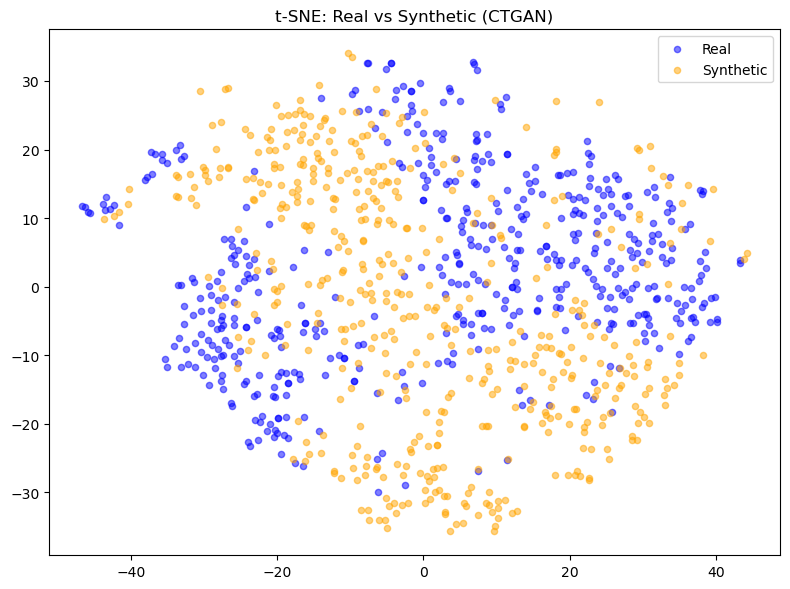

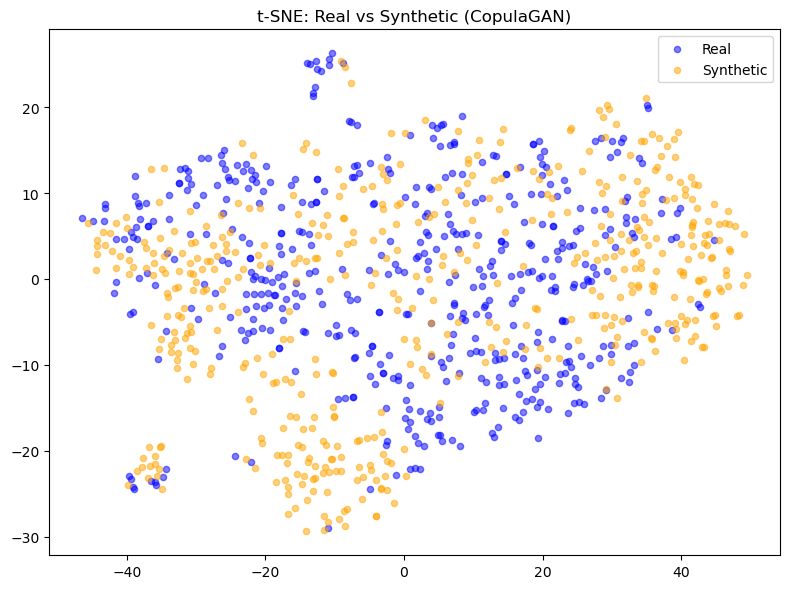

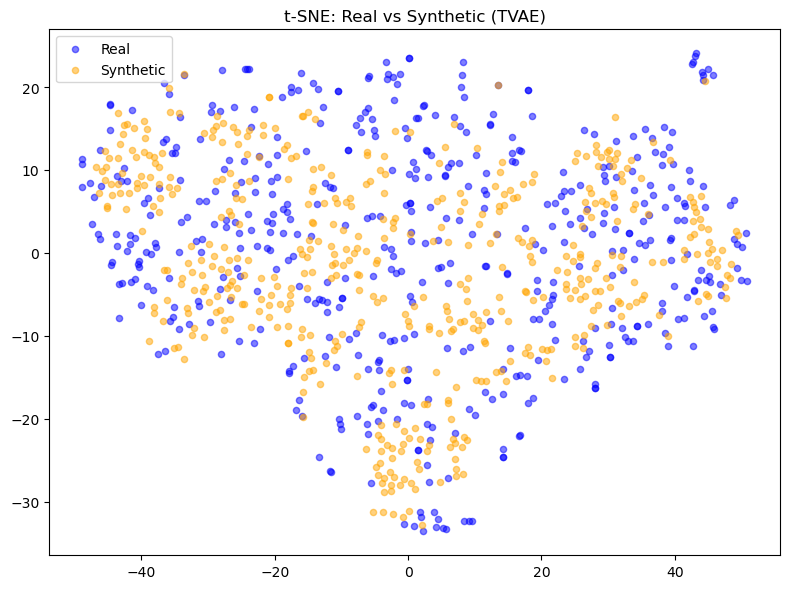

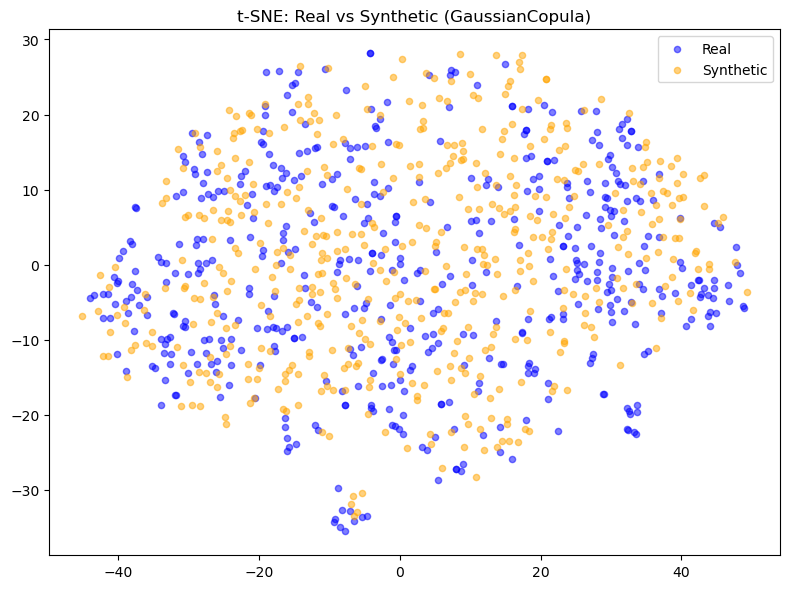

In [16]:
from sklearn.manifold import TSNE

for model_name, synth_df in synthetic_data_dict.items():
    numeric_cols = [c for c in wine_data.select_dtypes(include=[np.number]).columns if c in synth_df.columns]
    scaler = StandardScaler().fit(wine_data[numeric_cols])
    real_scaled = pd.DataFrame(scaler.transform(wine_data[numeric_cols]), columns=numeric_cols)
    synth_scaled = pd.DataFrame(scaler.transform(synth_df[numeric_cols]), columns=numeric_cols)
    n_real = min(500, len(real_scaled))
    n_synth = min(500, len(synth_scaled))
    combined = np.vstack([real_scaled.sample(n_real, random_state=42), synth_scaled.sample(n_synth, random_state=42)])
    labels = ['Real'] * n_real + ['Synthetic'] * n_synth
    X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(combined)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[:n_real, 0], X_tsne[:n_real, 1], c='blue', alpha=0.5, label='Real', s=20)
    plt.scatter(X_tsne[n_real:, 0], X_tsne[n_real:, 1], c='orange', alpha=0.5, label='Synthetic', s=20)
    plt.title(f't-SNE: Real vs Synthetic ({model_name})')
    plt.legend()
    plt.tight_layout()
    plt.show()